# 🏠 Irish Rental Crisis — Analysis & Prediction Platform
## Notebook 03: Exploratory Data Analysis

---

Ireland has one of the worst rental crises in Europe. Rents have been climbing since 2012 and show no real sign of stopping. This notebook digs into the data to understand *where*, *when*, *how fast*, and *who gets hit hardest*.

The questions I want to answer here:
- How bad has the national trend actually been, and did COVID change anything?
- Which counties are the most expensive and which are still affordable?
- Is the crisis a Dublin problem or has it spread?
- Who genuinely can't afford rent anymore — and what does the affordability data say?
- What's happening with HAP? Is state support keeping up or falling further behind?

The analysis uses four clean datasets from Notebook 02. Two are core rent datasets (quarterly from 2015, annual back to 2008). Two are context datasets with affordability, landlord income, HAP, and population at county and LEA level.

---

| Dataset | What it contains |
|---------|-----------------|
| `rent_quarterly_clean.csv` | RTB quarterly rent — 210,865 rows, 2015–2025 |
| `rent_annual_clean.csv` | RTB annual rent — 109,380 rows, 2008–2024 |
| `context_county_clean.csv` | Landlord income, affordability, population — 29 counties |
| `context_lea_clean.csv` | HAP, income, affordability — 166 LEAs × 8 years |

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('ready.')

ready.


In [2]:
df_q   = pd.read_csv('/content/rent_quarterly_clean.csv')
df_a   = pd.read_csv('/content/rent_annual_clean.csv')
df_cc  = pd.read_csv('/content/context_county_clean.csv')
df_lea = pd.read_csv('/content/context_lea_clean.csv')

print(f'rent_quarterly  : {df_q.shape[0]:,} rows | {df_q.shape[1]} cols')
print(f'rent_annual     : {df_a.shape[0]:,} rows | {df_a.shape[1]} cols')
print(f'context_county  : {df_cc.shape[0]:,} rows | {df_cc.shape[1]} cols')
print(f'context_lea     : {df_lea.shape[0]:,} rows | {df_lea.shape[1]} cols')

rent_quarterly  : 210,865 rows | 7 cols
rent_annual     : 109,380 rows | 5 cols
context_county  : 29 rows | 6 cols
context_lea     : 1,328 rows | 8 cols


In [3]:
# quick sense check before diving in
print('Monthly rent — basic stats:')
print(df_q['Value'].describe().round(0))
print()
print(f'Year range     : {df_q["Year"].min()} to {df_q["Year"].max()}')
print(f'Locations      : {df_q["Location"].nunique()}')
print(f'Property types : {list(df_q["PropertyType"].unique())}')
print(f'Bedroom types  : {list(df_q["Bedrooms"].unique())}')

Monthly rent — basic stats:
count    210865.0
mean       1160.0
std         519.0
min         234.0
25%         748.0
50%        1074.0
75%        1478.0
max        6522.0
Name: Value, dtype: float64

Year range     : 2015 to 2025
Locations      : 434
Property types : ['All property types', 'Detached house', 'Semi detached house', 'Terrace house', 'Apartment', 'Other flats']
Bedroom types  : ['All bedrooms', 'One bed', 'Two bed', 'Three bed', '1 to 2 bed', '1 to 3 bed', 'Four plus bed']


The average monthly rent across all records is somewhere in the €1,200–€1,400 range but that figure hides a lot. Dublin pulls the mean up hard. The min and max values will be interesting — there are always some extreme outliers in Irish rental data.

---
## 1. How bad has the national trend actually been?

Starting with the big picture — national average rent by quarter from 2015 to 2025. This is the headline number.

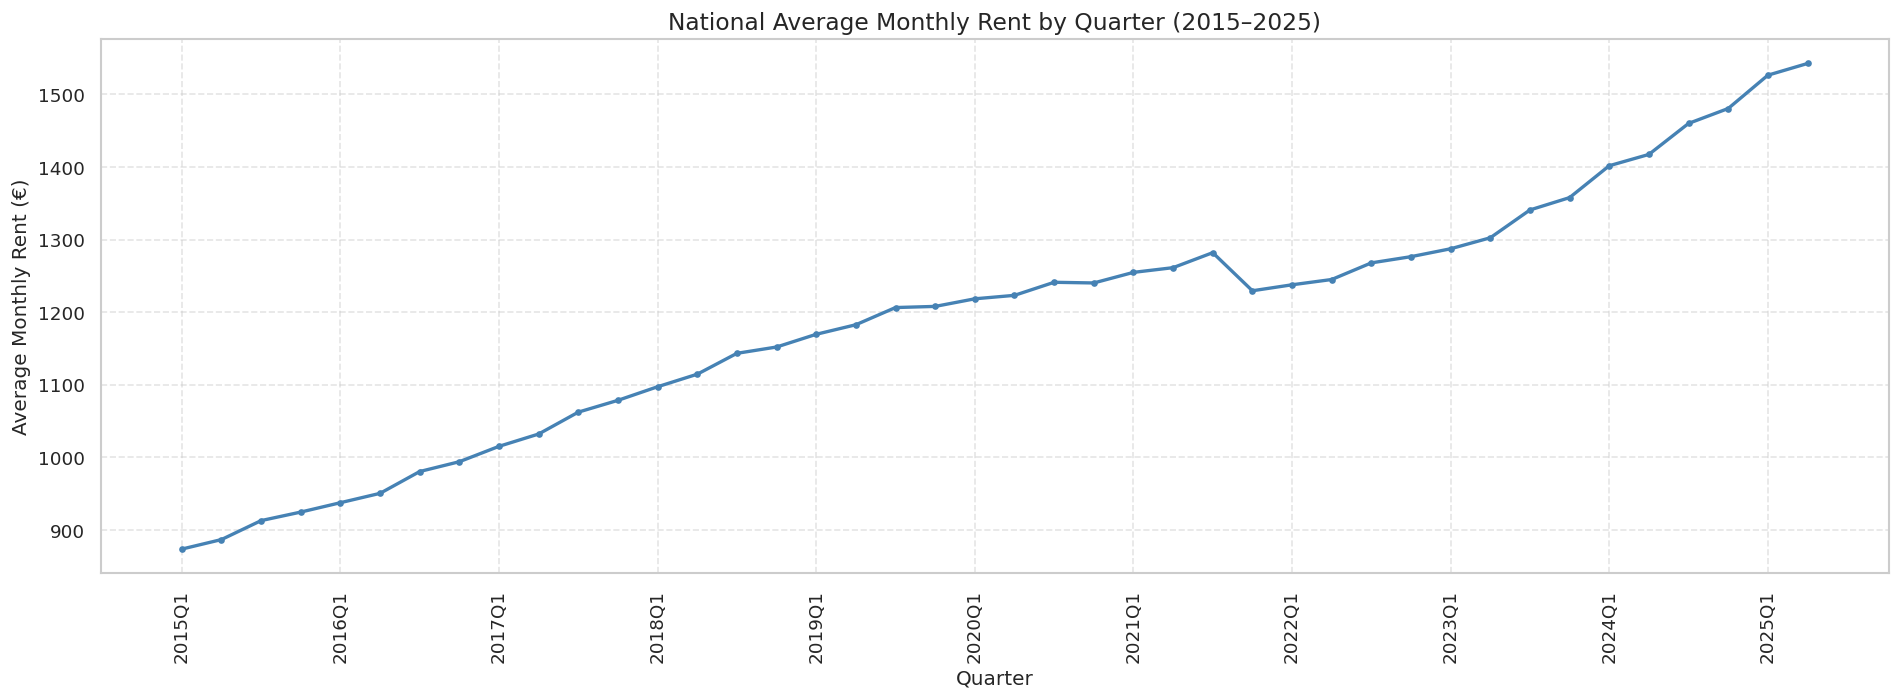

In [4]:
national_q = df_q.groupby('Quarter')['Value'].mean().reset_index()
national_q['Year']  = national_q['Quarter'].str.extract(r'(\d{4})').astype(int)
national_q['Q_Num'] = national_q['Quarter'].str.extract(r'Q(\d)').astype(int)
national_q['Sort']  = national_q['Year'] * 4 + national_q['Q_Num']
national_q = national_q.sort_values('Sort').reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(range(len(national_q)), national_q['Value'], marker='o', markersize=3,
         color='steelblue', linewidth=2)
plt.xticks(range(0, len(national_q), 4), national_q['Quarter'][::4], rotation=90)
plt.title('National Average Monthly Rent by Quarter (2015–2025)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Average Monthly Rent (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pretty relentless. One dip around 2020 — that's COVID — and then straight back up again. There's no plateau, no levelling off. If anything the post-COVID climb looks steeper than what came before it. The brief relief people might have felt in 2020 was gone within a year.

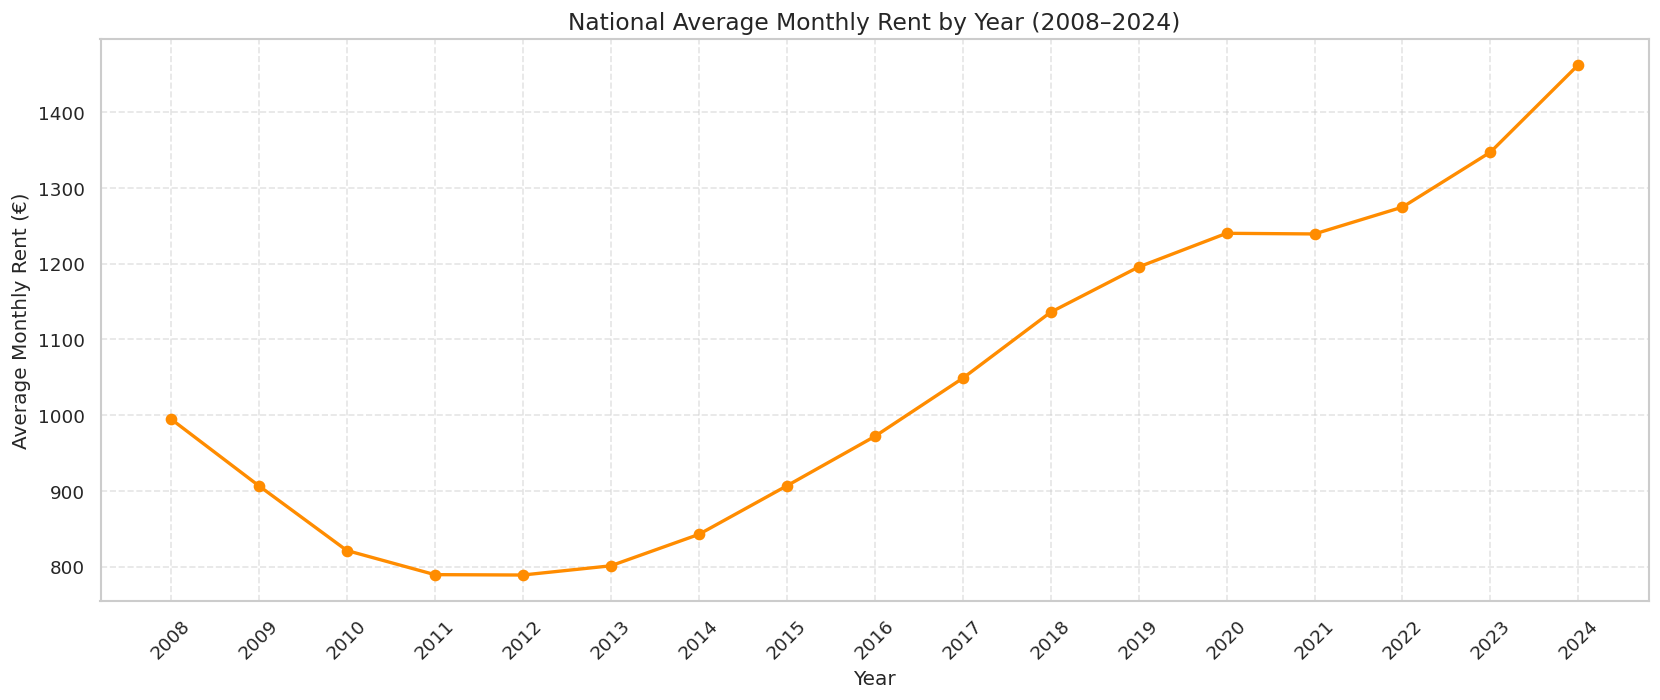

In [5]:
# go further back to 2008 using the annual dataset
national_a = df_a.groupby('Year')['Value'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(national_a['Year'], national_a['Value'], marker='o', color='darkorange', linewidth=2)
plt.title('National Average Monthly Rent by Year (2008–2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Monthly Rent (€)')
plt.xticks(national_a['Year'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This is the full story. Rents collapsed after the financial crash — bottomed out around 2011–2012 — then climbed non-stop for over a decade. The crisis didn't start in 2015, that's just when RTB started collecting quarterly data. It was already well underway. By 2024 the average rent is more than double what it was at the 2012 low.

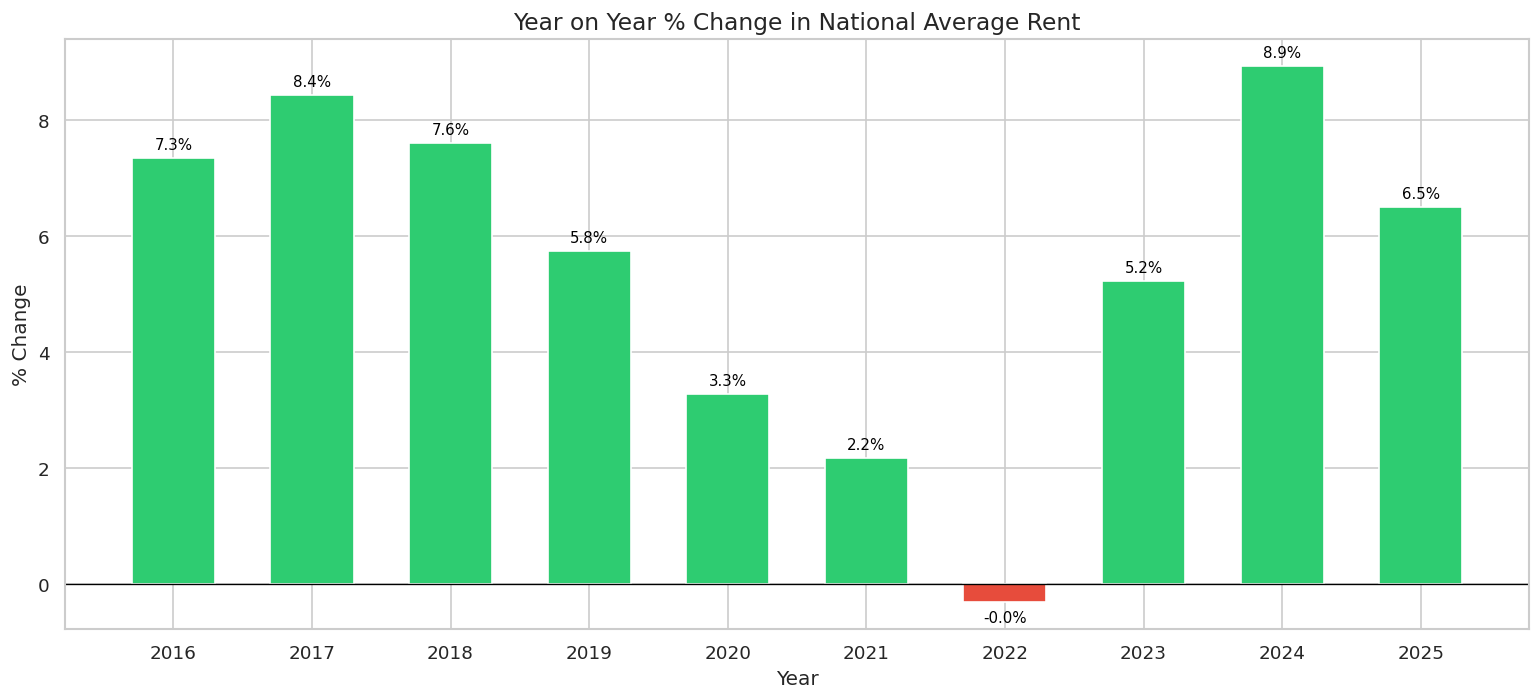

In [39]:
# year on year % change — which years were the worst
national_yr = df_q.groupby('Year')['Value'].mean().reset_index()
national_yr['YoY_Change'] = national_yr['Value'].pct_change() * 100
national_yr = national_yr.dropna()

# force minimum bar height so near-zero values are still visible
national_yr['Bar_Height'] = national_yr['YoY_Change'].apply(
    lambda x: -0.3 if (x < 0 and abs(x) < 0.3) else x
)

plt.figure(figsize=(13, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in national_yr['YoY_Change']]
bars = plt.bar(national_yr['Year'], national_yr['Bar_Height'], color=colors, width=0.6)

# value labels on each bar
for bar, val in zip(bars, national_yr['YoY_Change']):
    ypos = bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.4
    plt.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Year on Year % Change in National Average Rent', fontsize=14)
plt.xlabel('Year')
plt.ylabel('% Change')
plt.xticks(national_yr['Year'])
plt.tight_layout()
plt.show()

2020 was the only year rents actually fell — and even then it wasn't by much. 2021 bounced back hard, nearly matching the worst years of 2015–2017. The interesting thing is there's no single catastrophic year — it's been a slow, grinding increase every year that compounds into something enormous over a decade.

---
## 2. Which counties are most expensive — and is this just a Dublin problem?

In [37]:
national_yr = df_q.groupby('Year')['Value'].mean().reset_index()
national_yr['YoY_Change'] = national_yr['Value'].pct_change() * 100
print(national_yr)

    Year        Value  YoY_Change
0   2015   899.567925         NaN
1   2016   965.681877    7.349523
2   2017  1047.085863    8.429690
3   2018  1126.812762    7.614170
4   2019  1191.655966    5.754568
5   2020  1230.782393    3.283366
6   2021  1257.576058    2.176962
7   2022  1257.213311   -0.028845
8   2023  1322.921924    5.226529
9   2024  1441.157338    8.937445
10  2025  1534.902588    6.504859


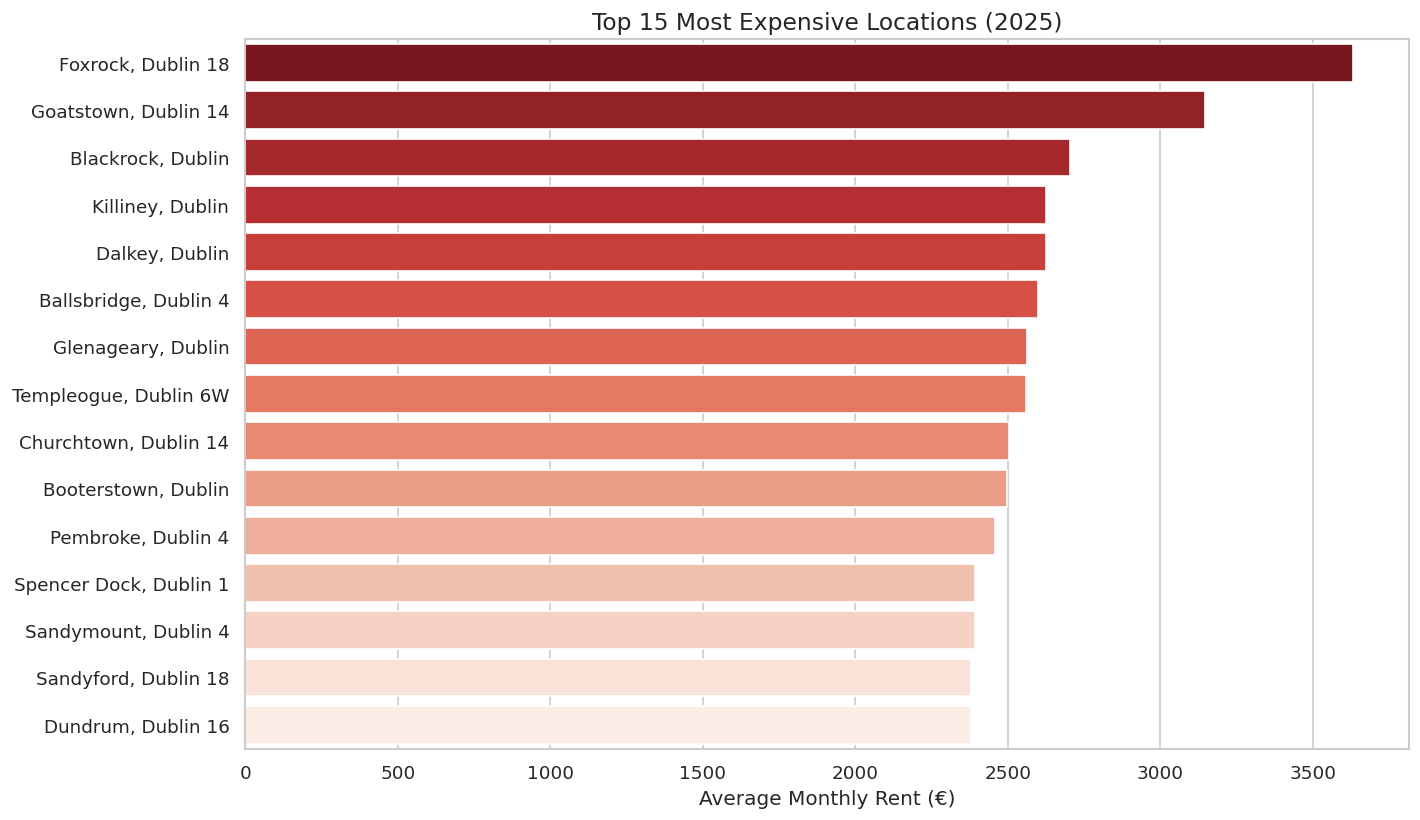

In [7]:
latest_year   = df_q['Year'].max()
county_latest = df_q[df_q['Year'] == latest_year].groupby('Location')['Value'].mean().reset_index()
county_latest = county_latest.sort_values('Value', ascending=False).reset_index(drop=True)

top15 = county_latest.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top15, x='Value', y='Location', palette='Reds_r')
plt.title(f'Top 15 Most Expensive Locations ({latest_year})', fontsize=14)
plt.xlabel('Average Monthly Rent (€)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Dublin is clearly the most expensive but look at what's behind it — Wicklow, Kildare, Meath. These are commuter counties. People who got priced out of Dublin moved there and brought the demand with them. The crisis isn't contained to the capital anymore.

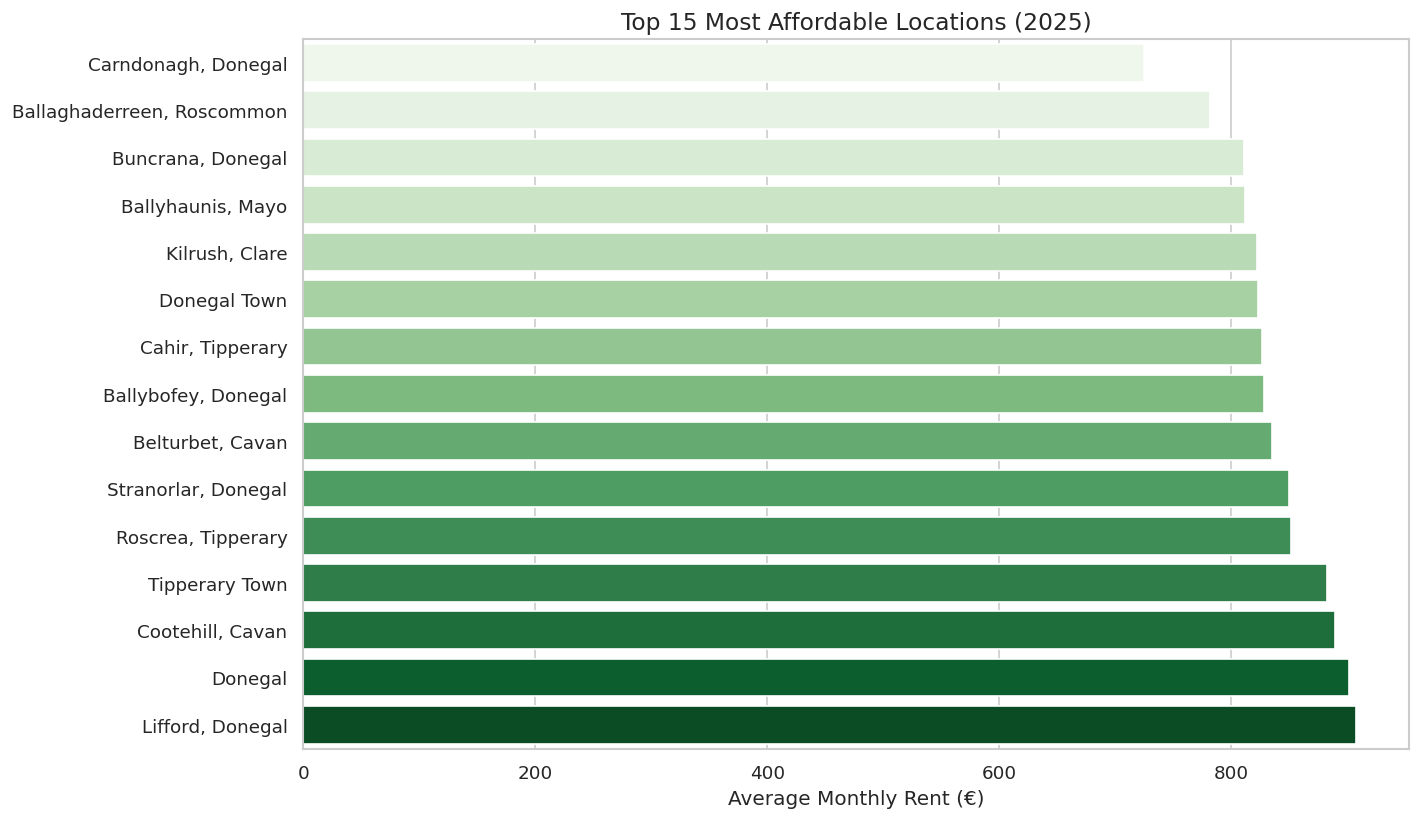

In [8]:
bottom15 = county_latest.tail(15).sort_values('Value')

plt.figure(figsize=(12, 7))
sns.barplot(data=bottom15, x='Value', y='Location', palette='Greens')
plt.title(f'Top 15 Most Affordable Locations ({latest_year})', fontsize=14)
plt.xlabel('Average Monthly Rent (€)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Leitrim, Roscommon, Longford — these are genuinely still affordable by Irish standards. But affordable relative to Dublin means very little if there are no jobs there. The affordability gap between these areas and the major cities is huge, but it comes with real tradeoffs.

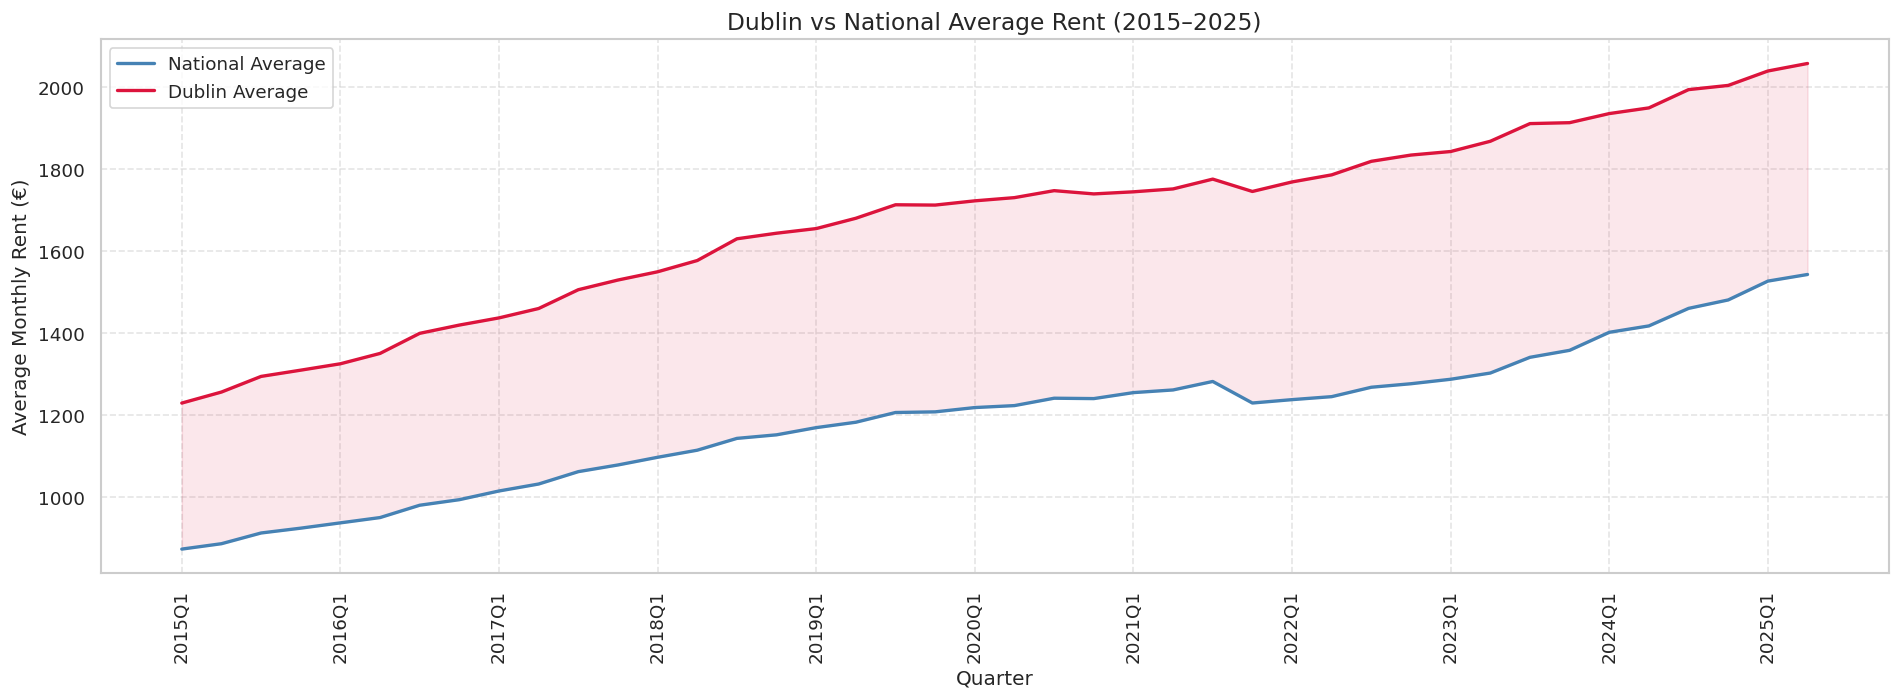

In [9]:
# Dublin vs national — how wide is the gap and is it growing?
dublin_q = df_q[df_q['Location'].str.contains('Dublin', case=False, na=False)]
dublin_avg = dublin_q.groupby('Quarter')['Value'].mean().reset_index()
dublin_avg['Sort'] = dublin_avg['Quarter'].str.extract(r'(\d{4})').astype(int) * 4 +                      dublin_avg['Quarter'].str.extract(r'Q(\d)').astype(int)
dublin_avg = dublin_avg.sort_values('Sort').reset_index(drop=True)

min_len = min(len(national_q), len(dublin_avg))
x = range(min_len)

plt.figure(figsize=(16, 6))
plt.plot(x, national_q['Value'][:min_len], label='National Average', color='steelblue', linewidth=2)
plt.plot(x, dublin_avg['Value'][:min_len], label='Dublin Average', color='crimson', linewidth=2)
plt.fill_between(x, national_q['Value'][:min_len], dublin_avg['Value'][:min_len],
                 alpha=0.1, color='crimson')
plt.xticks(range(0, min_len, 4), national_q['Quarter'][:min_len:4], rotation=90)
plt.title('Dublin vs National Average Rent (2015–2025)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Average Monthly Rent (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The shaded area between the two lines tells the real story — that gap has been getting wider every year. Dublin isn't just expensive, it's pulling away. A renter in Dublin is now paying several hundred euros more per month than the national average and that premium keeps growing.

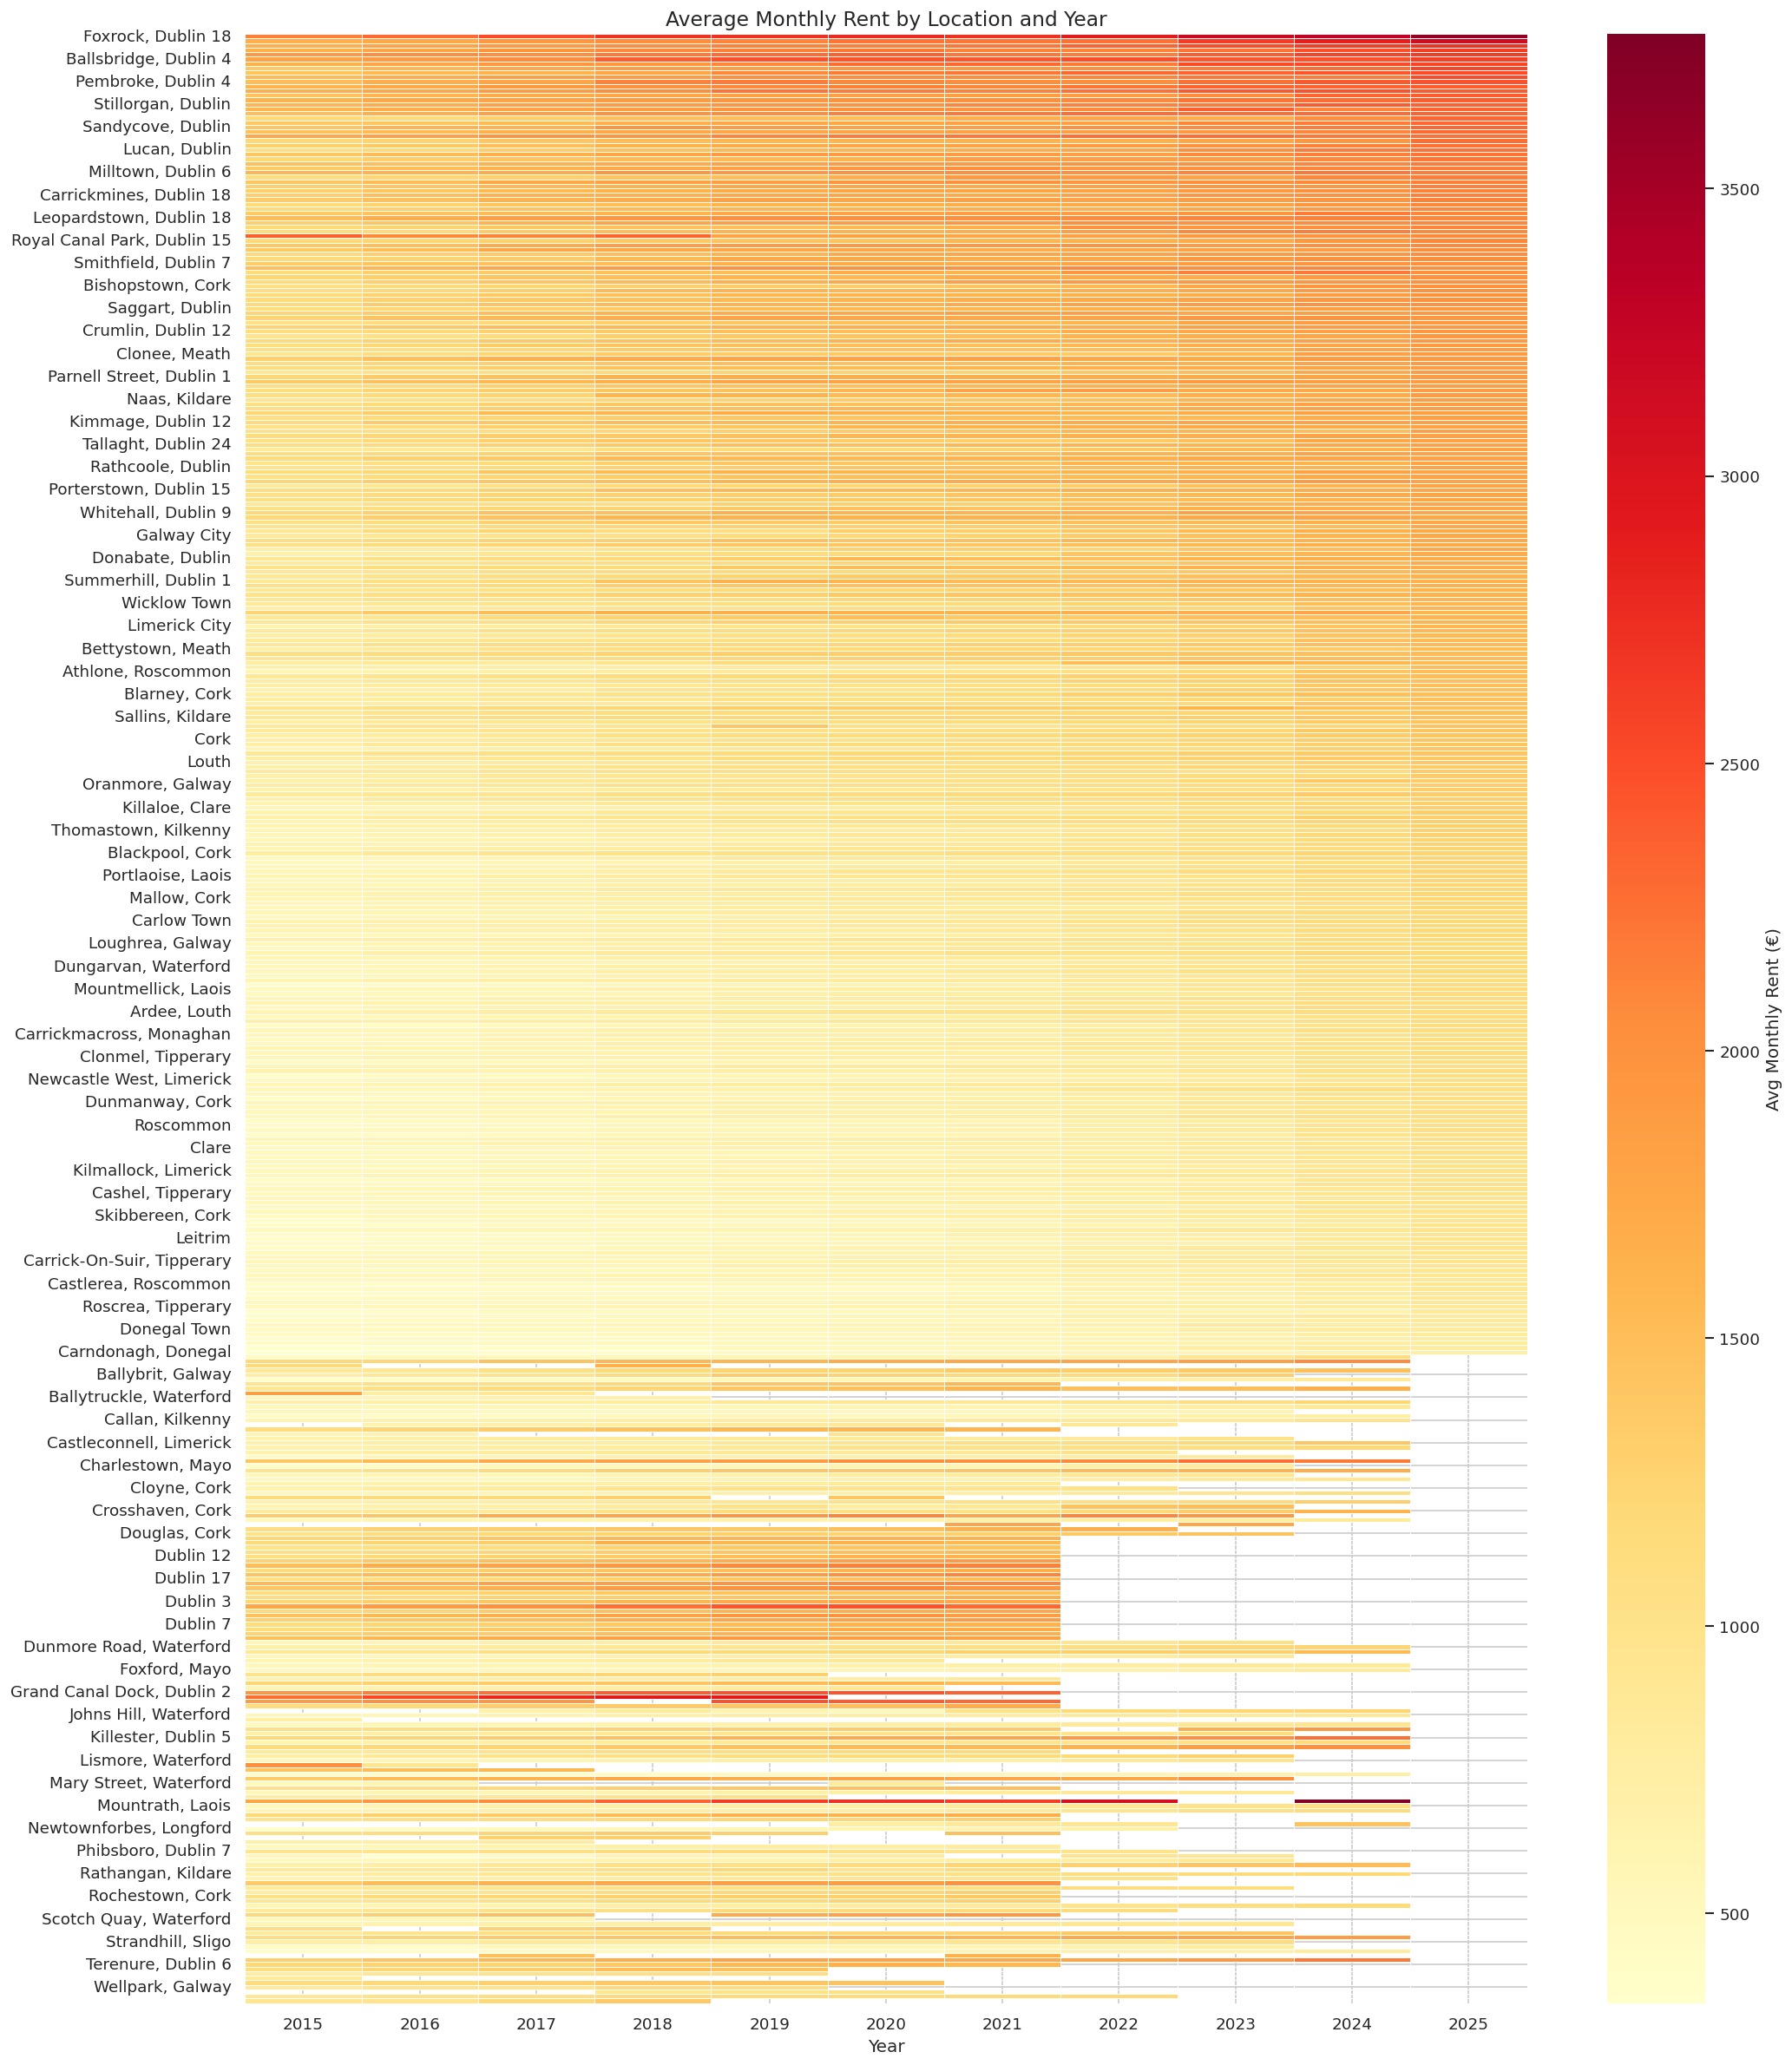

In [10]:
# heatmap — every location across every year
county_year = df_q.groupby(['Location', 'Year'])['Value'].mean().reset_index()
pivot = county_year.pivot(index='Location', columns='Year', values='Value')
pivot = pivot.sort_values(pivot.columns[-1], ascending=False)

plt.figure(figsize=(18, 20))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, annot=False,
            cbar_kws={'label': 'Avg Monthly Rent (€)'})
plt.title('Average Monthly Rent by Location and Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('')
plt.tight_layout()
plt.show()

What I like about this view is you can see the pattern across the whole country at once. The top rows (Dublin, Wicklow, Kildare) go dark quickly and stay dark. The bottom rows (Leitrim, Roscommon) barely change colour across the years. But look at the middle — counties that were pale in 2015 are noticeably darker by 2023. The crisis has been spreading downward through the list.

---
## 3. Property type and bedrooms — who pays the most per square foot?

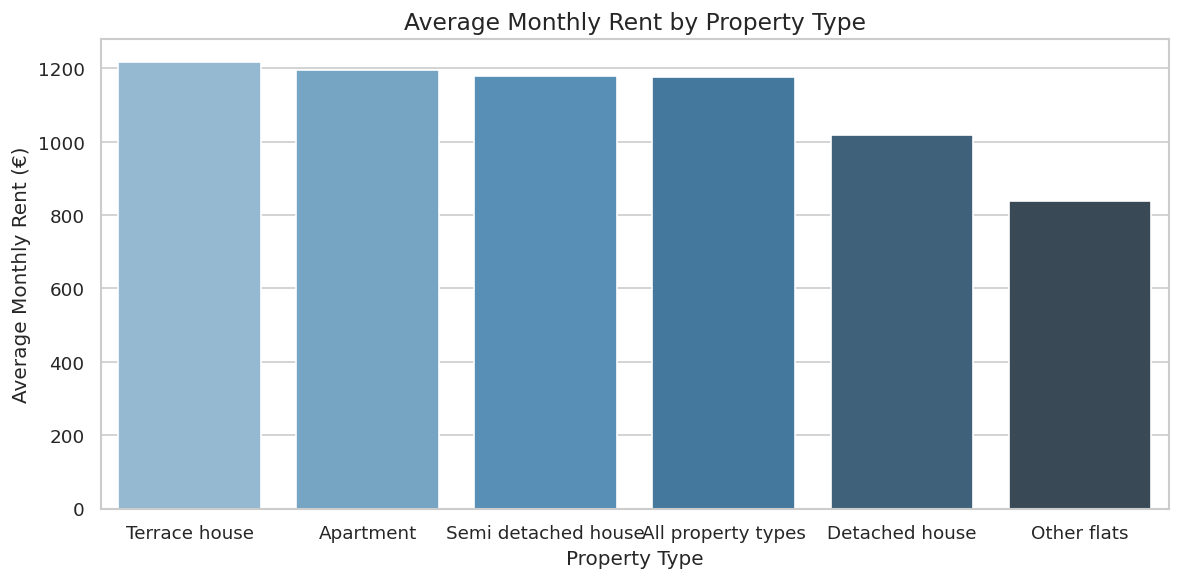

In [11]:
prop_avg = df_q.groupby('PropertyType')['Value'].mean().reset_index().sort_values('Value', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=prop_avg, x='PropertyType', y='Value', palette='Blues_d')
plt.title('Average Monthly Rent by Property Type', fontsize=14)
plt.xlabel('Property Type')
plt.ylabel('Average Monthly Rent (€)')
plt.tight_layout()
plt.show()

Houses are more expensive in absolute terms but that's partly because they're bigger. The more interesting question is what you get for your money — that's what the cost per bedroom chart below shows.

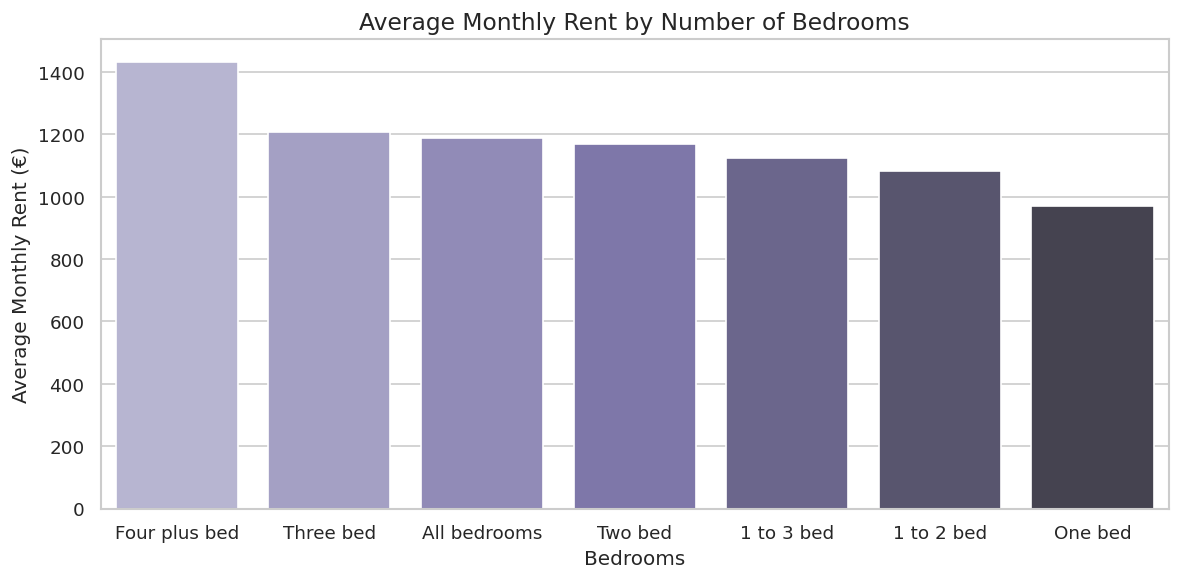

In [12]:
bed_avg = df_q.groupby('Bedrooms')['Value'].mean().reset_index().sort_values('Value', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=bed_avg, x='Bedrooms', y='Value', palette='Purples_d')
plt.title('Average Monthly Rent by Number of Bedrooms', fontsize=14)
plt.xlabel('Bedrooms')
plt.ylabel('Average Monthly Rent (€)')
plt.tight_layout()
plt.show()

Straightforward — more bedrooms, more rent. But the gap between 1-bed and 2-bed is proportionally bigger than the gaps higher up. That 1-bed to 2-bed jump is where a lot of renters get squeezed — a second bedroom doesn't cost half as much again, it costs nearly as much again.

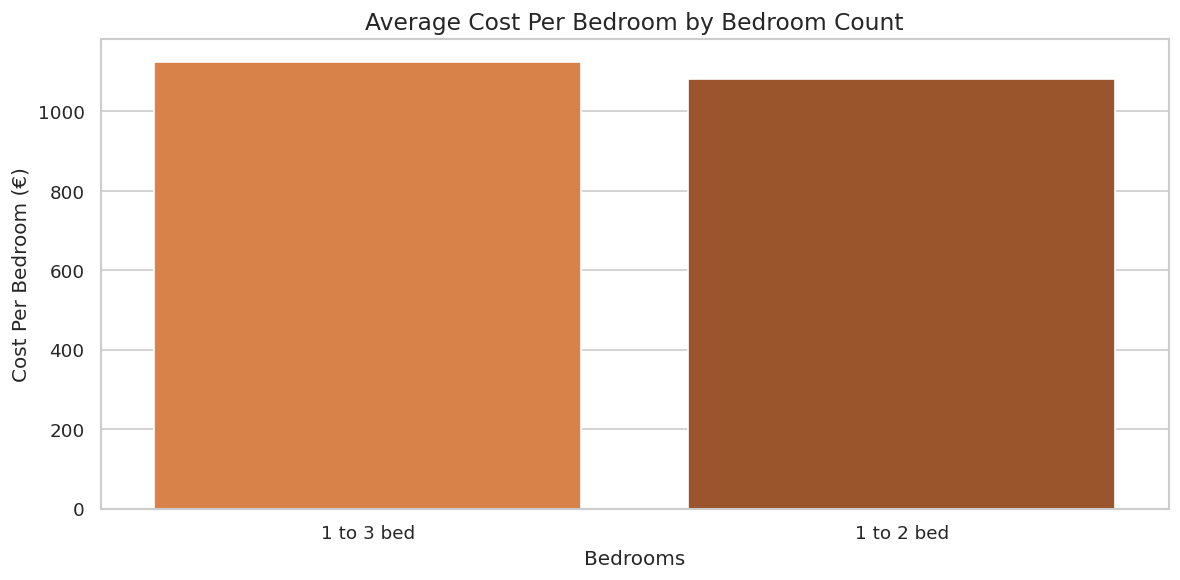

In [13]:
df_q_bed = df_q[~df_q['Bedrooms'].str.lower().isin(['all bedrooms'])].copy()
df_q_bed['Bed_Num'] = df_q_bed['Bedrooms'].str.extract(r'(\d)').astype(float)
df_q_bed = df_q_bed.dropna(subset=['Bed_Num'])
df_q_bed['Cost_Per_Bedroom'] = df_q_bed['Value'] / df_q_bed['Bed_Num']

cpb = df_q_bed.groupby('Bedrooms')['Cost_Per_Bedroom'].mean().reset_index().sort_values('Cost_Per_Bedroom', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=cpb, x='Bedrooms', y='Cost_Per_Bedroom', palette='Oranges_d')
plt.title('Average Cost Per Bedroom by Bedroom Count', fontsize=14)
plt.xlabel('Bedrooms')
plt.ylabel('Cost Per Bedroom (€)')
plt.tight_layout()
plt.show()

This is the one that surprises people. A 1-bed renter is paying the most per bedroom of anyone in the market. The more bedrooms you have, the cheaper each one gets. If you're living alone in a 1-bed apartment in Dublin you are paying a premium in every direction — absolute price, cost per room, and proportion of income.

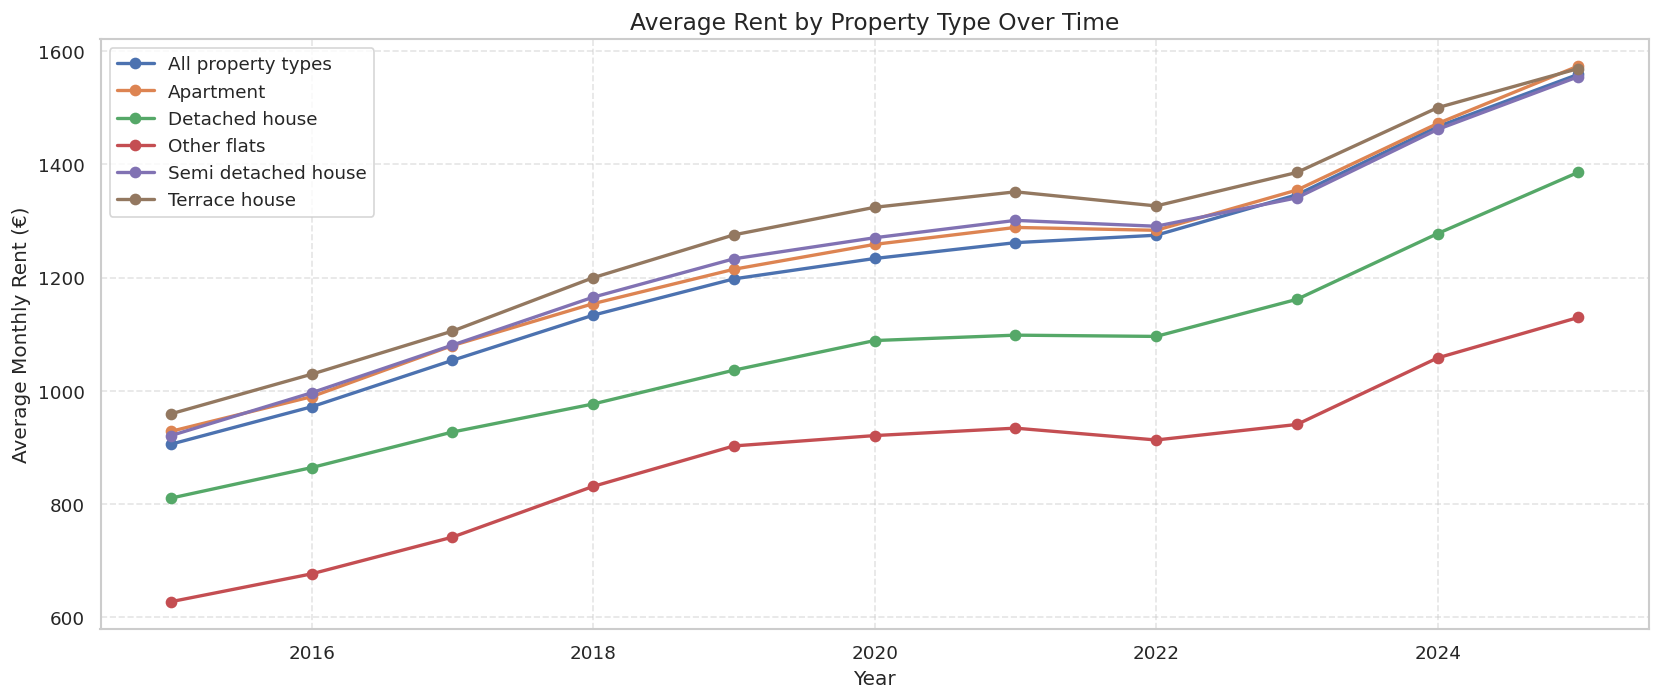

In [14]:
prop_trend = df_q.groupby(['Year', 'PropertyType'])['Value'].mean().reset_index()

plt.figure(figsize=(14, 6))
for ptype in prop_trend['PropertyType'].unique():
    data = prop_trend[prop_trend['PropertyType'] == ptype]
    plt.plot(data['Year'], data['Value'], marker='o', label=ptype, linewidth=2)

plt.title('Average Rent by Property Type Over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Monthly Rent (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

All property types rose together and the gaps between them stayed roughly the same throughout. This rules out the idea that one specific housing type drove the crisis — the whole market moved up in parallel.

---
## 4. Where has rent grown fastest since 2015?

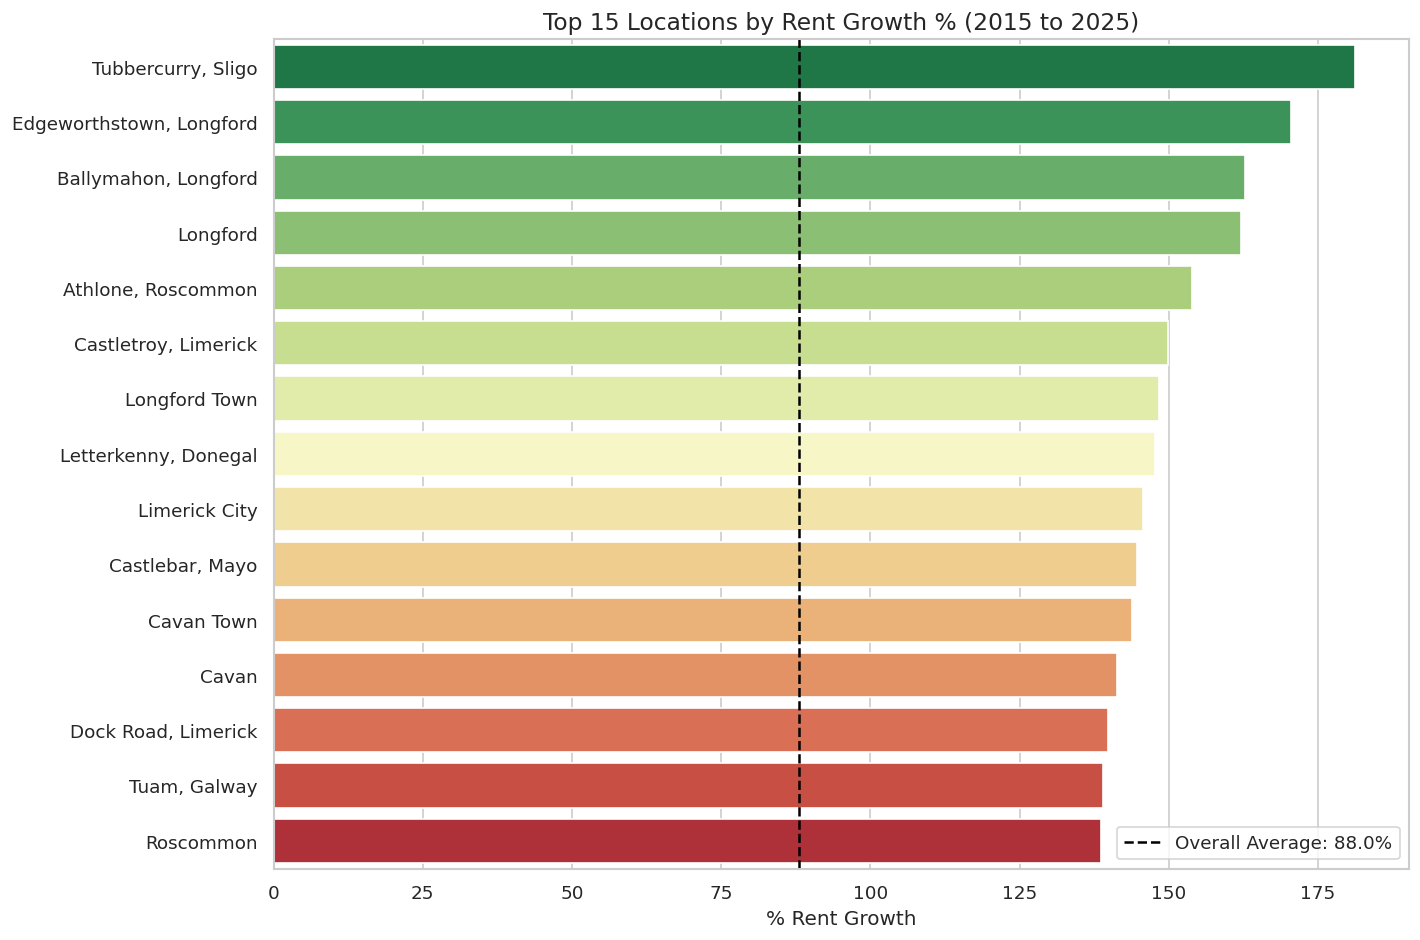

In [15]:
county_2015 = df_q[df_q['Year'] == 2015].groupby('Location')['Value'].mean()
county_now  = df_q[df_q['Year'] == latest_year].groupby('Location')['Value'].mean()

growth = pd.DataFrame({'Rent_2015': county_2015, 'Rent_Now': county_now}).dropna()
growth['Growth_Pct'] = ((growth['Rent_Now'] - growth['Rent_2015']) / growth['Rent_2015']) * 100
growth = growth.reset_index().sort_values('Growth_Pct', ascending=False)

top15_growth = growth.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top15_growth, x='Growth_Pct', y='Location', palette='RdYlGn_r')
plt.axvline(growth['Growth_Pct'].mean(), color='black', linestyle='--',
            label=f'Overall Average: {growth["Growth_Pct"].mean():.1f}%')
plt.title(f'Top 15 Locations by Rent Growth % (2015 to {latest_year})', fontsize=14)
plt.xlabel('% Rent Growth')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

Some of these locations aren't the ones you'd expect at the top. It's not always the most expensive places that grew fastest — in some cases it's mid-tier commuter towns where rents were lower to start with and demand caught up hard. The dashed line shows the overall average — anything above it has grown faster than the national pace.

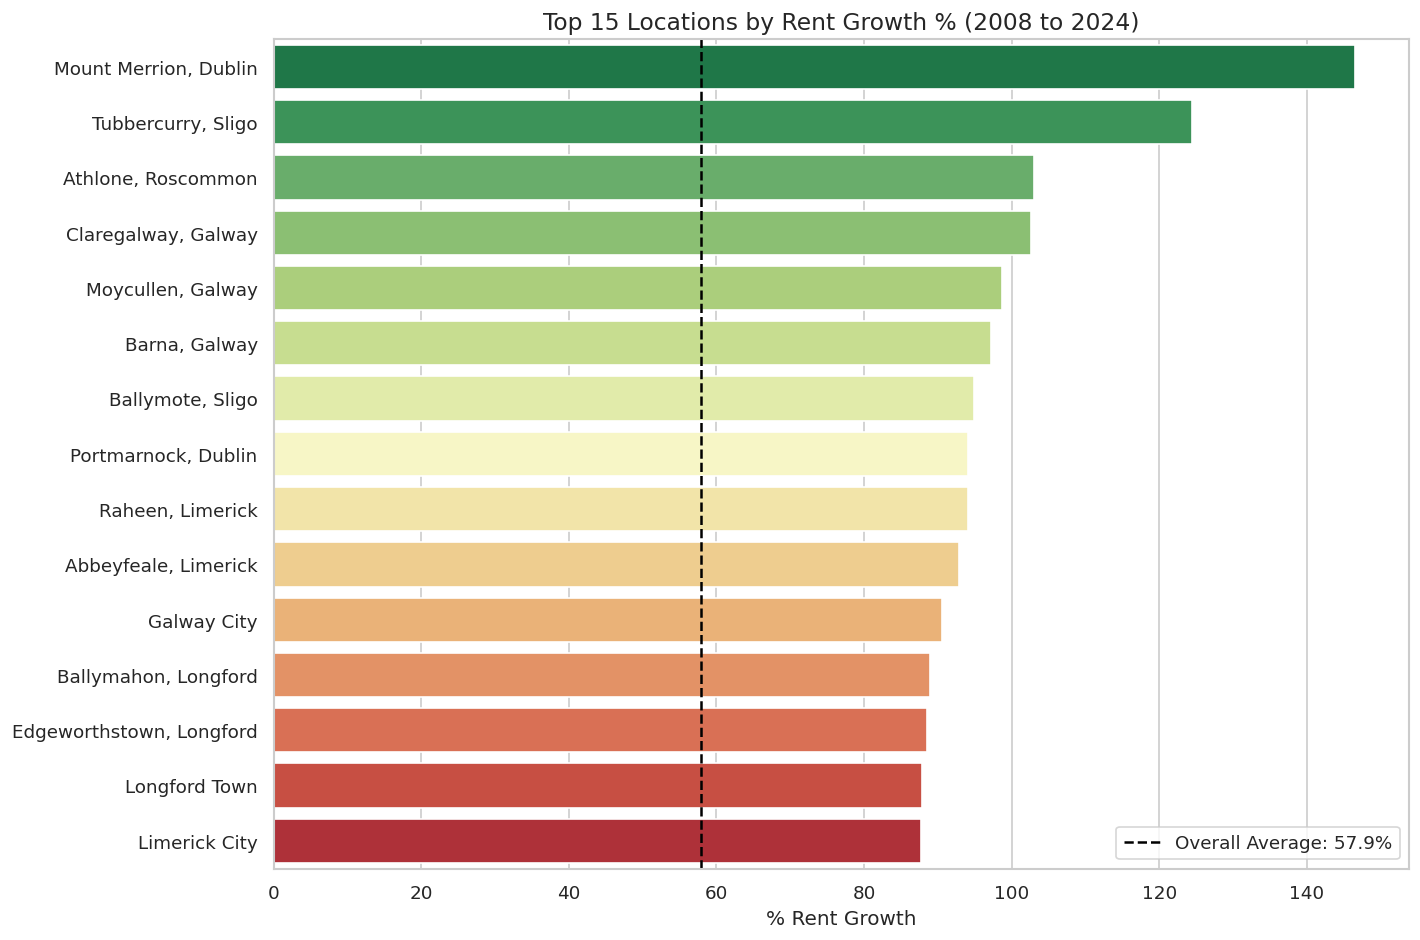

In [16]:
county_2008 = df_a[df_a['Year'] == 2008].groupby('Location')['Value'].mean()
county_2024 = df_a[df_a['Year'] == df_a['Year'].max()].groupby('Location')['Value'].mean()

growth_08 = pd.DataFrame({'Rent_2008': county_2008, 'Rent_2024': county_2024}).dropna()
growth_08['Growth_Pct'] = ((growth_08['Rent_2024'] - growth_08['Rent_2008']) / growth_08['Rent_2008']) * 100
growth_08 = growth_08.reset_index().sort_values('Growth_Pct', ascending=False)

top15_growth_08 = growth_08.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top15_growth_08, x='Growth_Pct', y='Location', palette='RdYlGn_r')
plt.axvline(growth_08['Growth_Pct'].mean(), color='black', linestyle='--',
            label=f'Overall Average: {growth_08["Growth_Pct"].mean():.1f}%')
plt.title(f'Top 15 Locations by Rent Growth % (2008 to {df_a["Year"].max()})', fontsize=14)
plt.xlabel('% Rent Growth')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

Going back to 2008 makes the numbers significantly bigger. Some locations have seen rents grow by well over 100% from their post-crash lows. This is why the rental crisis feels so acute for people who remember what it was like before 2012 — they're not imagining it, it really has more than doubled in many places.

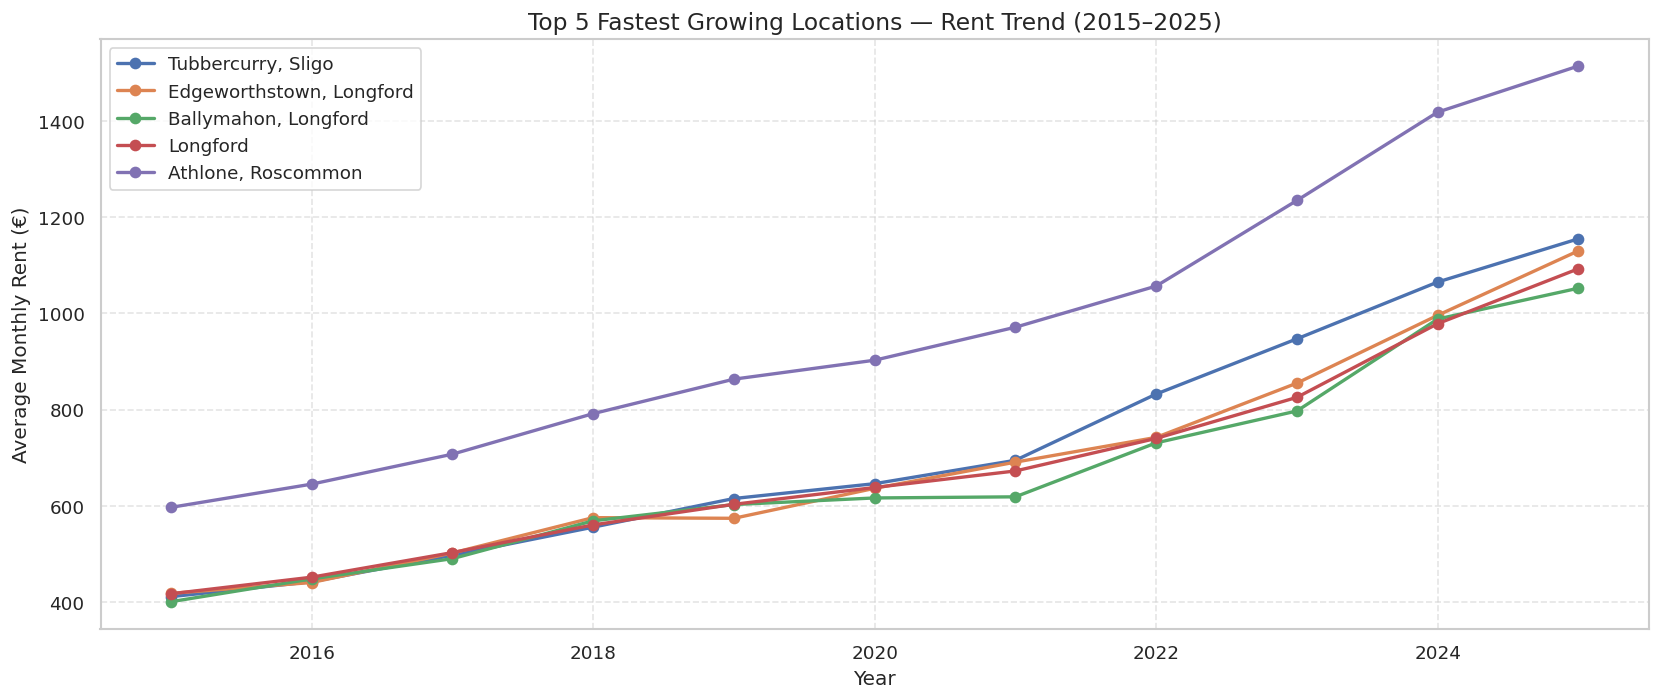

In [17]:
top5_locs  = growth.head(5)['Location'].tolist()
top5_data  = df_q[df_q['Location'].isin(top5_locs)]
top5_trend = top5_data.groupby(['Year', 'Location'])['Value'].mean().reset_index()

plt.figure(figsize=(14, 6))
for loc in top5_locs:
    data = top5_trend[top5_trend['Location'] == loc]
    plt.plot(data['Year'], data['Value'], marker='o', label=loc, linewidth=2)

plt.title('Top 5 Fastest Growing Locations — Rent Trend (2015–2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Monthly Rent (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

You can see the post-2020 acceleration clearly in these lines. The remote working shift changed where people could live and demand followed. Places that were growing steadily before COVID started climbing much faster after it.

---
## 5. COVID — did it actually help renters, or just delay the pain?

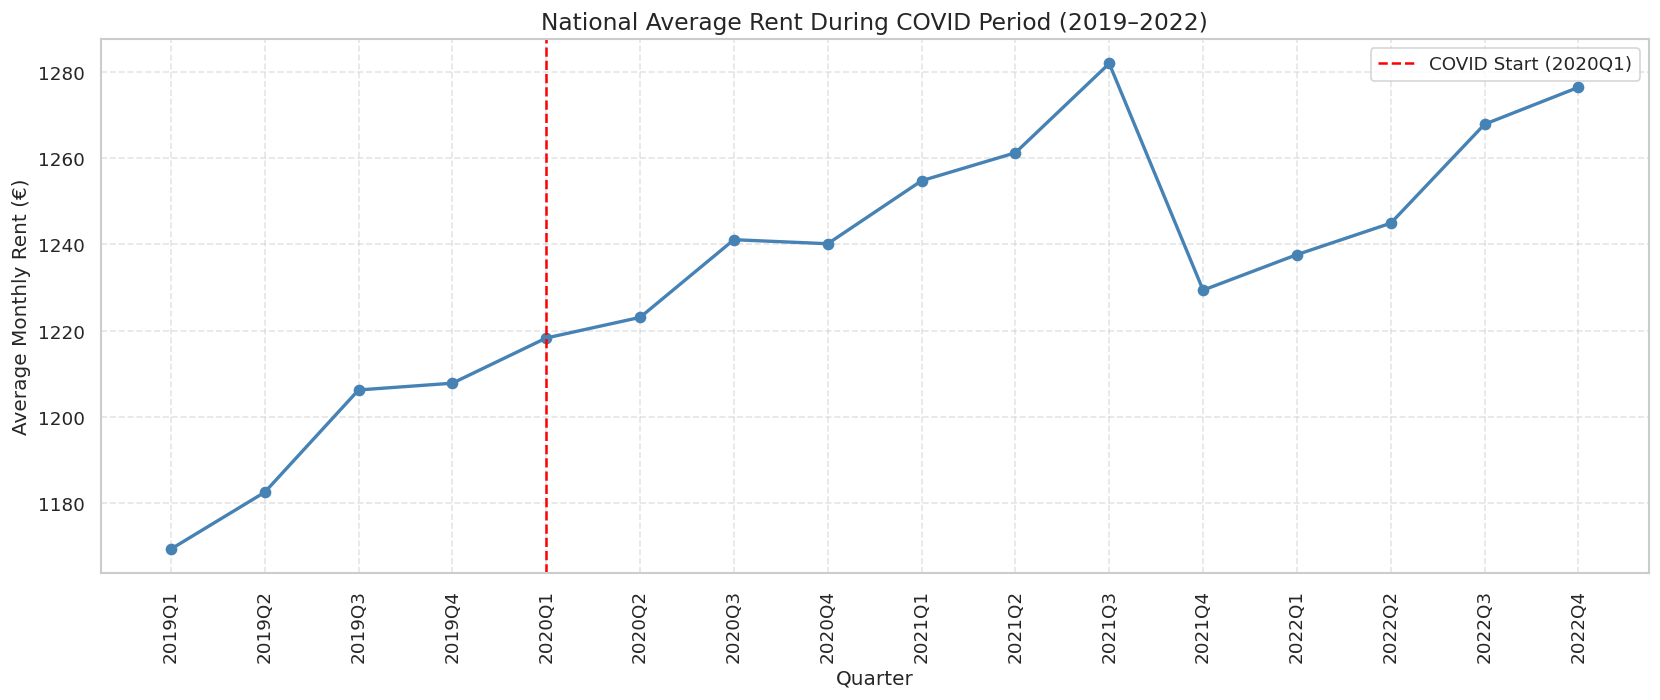

In [18]:
covid_window = national_q[(national_q['Year'] >= 2019) & (national_q['Year'] <= 2022)].reset_index(drop=True)
covid_start_idx = covid_window[covid_window['Quarter'] == '2020Q1'].index[0]

plt.figure(figsize=(14, 6))
plt.plot(range(len(covid_window)), covid_window['Value'], marker='o', color='steelblue', linewidth=2)
plt.axvline(x=covid_start_idx, color='red', linestyle='--', label='COVID Start (2020Q1)')
plt.xticks(range(len(covid_window)), covid_window['Quarter'], rotation=90)
plt.title('National Average Rent During COVID Period (2019–2022)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Average Monthly Rent (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Short answer: it delayed the pain. Rents dipped for about 3–4 quarters then bounced back sharply. By 2021 the national average had already recovered and by 2022 it was well above pre-COVID levels. For most renters the temporary relief would have been small and short-lived.

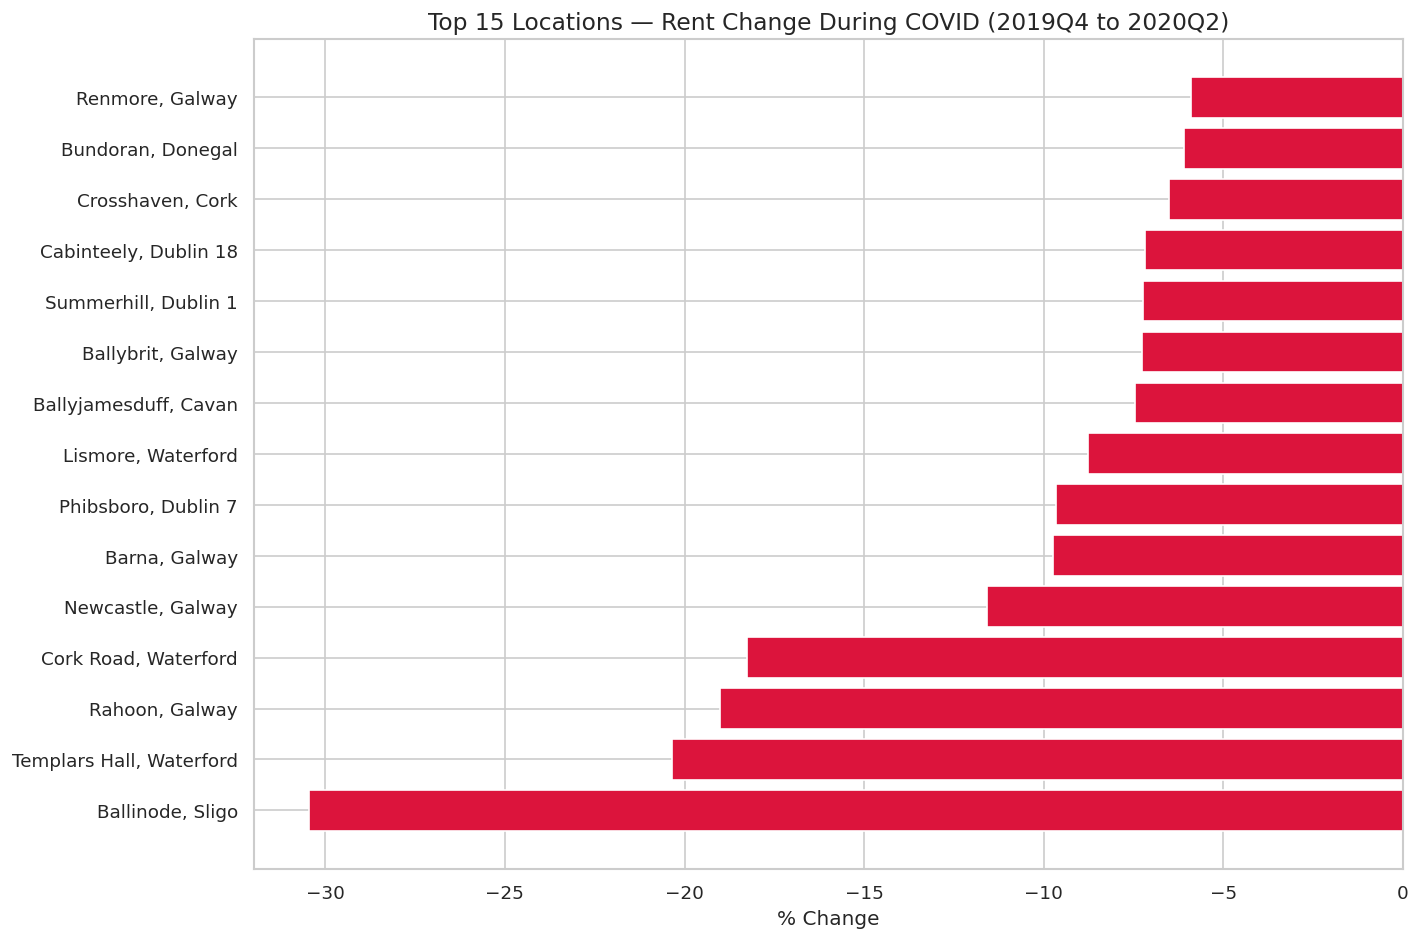

In [19]:
pre_covid  = df_q[df_q['Quarter'] == '2019Q4'].groupby('Location')['Value'].mean()
post_covid = df_q[df_q['Quarter'] == '2020Q2'].groupby('Location')['Value'].mean()

covid_drop = pd.DataFrame({'Pre': pre_covid, 'Post': post_covid}).dropna()
covid_drop['Drop_Pct'] = ((covid_drop['Post'] - covid_drop['Pre']) / covid_drop['Pre']) * 100
covid_drop = covid_drop.reset_index().sort_values('Drop_Pct')

top15_drop = covid_drop.head(15)

plt.figure(figsize=(12, 8))
colors = ['crimson' if x < 0 else 'steelblue' for x in top15_drop['Drop_Pct']]
plt.barh(top15_drop['Location'], top15_drop['Drop_Pct'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Locations — Rent Change During COVID (2019Q4 to 2020Q2)', fontsize=14)
plt.xlabel('% Change')
plt.ylabel('')
plt.tight_layout()
plt.show()

The biggest drops happened in urban areas — makes sense. When offices emptied out, demand for city-centre apartments fell fast. Rural and suburban areas actually held up better during this period because those renters weren't going anywhere.

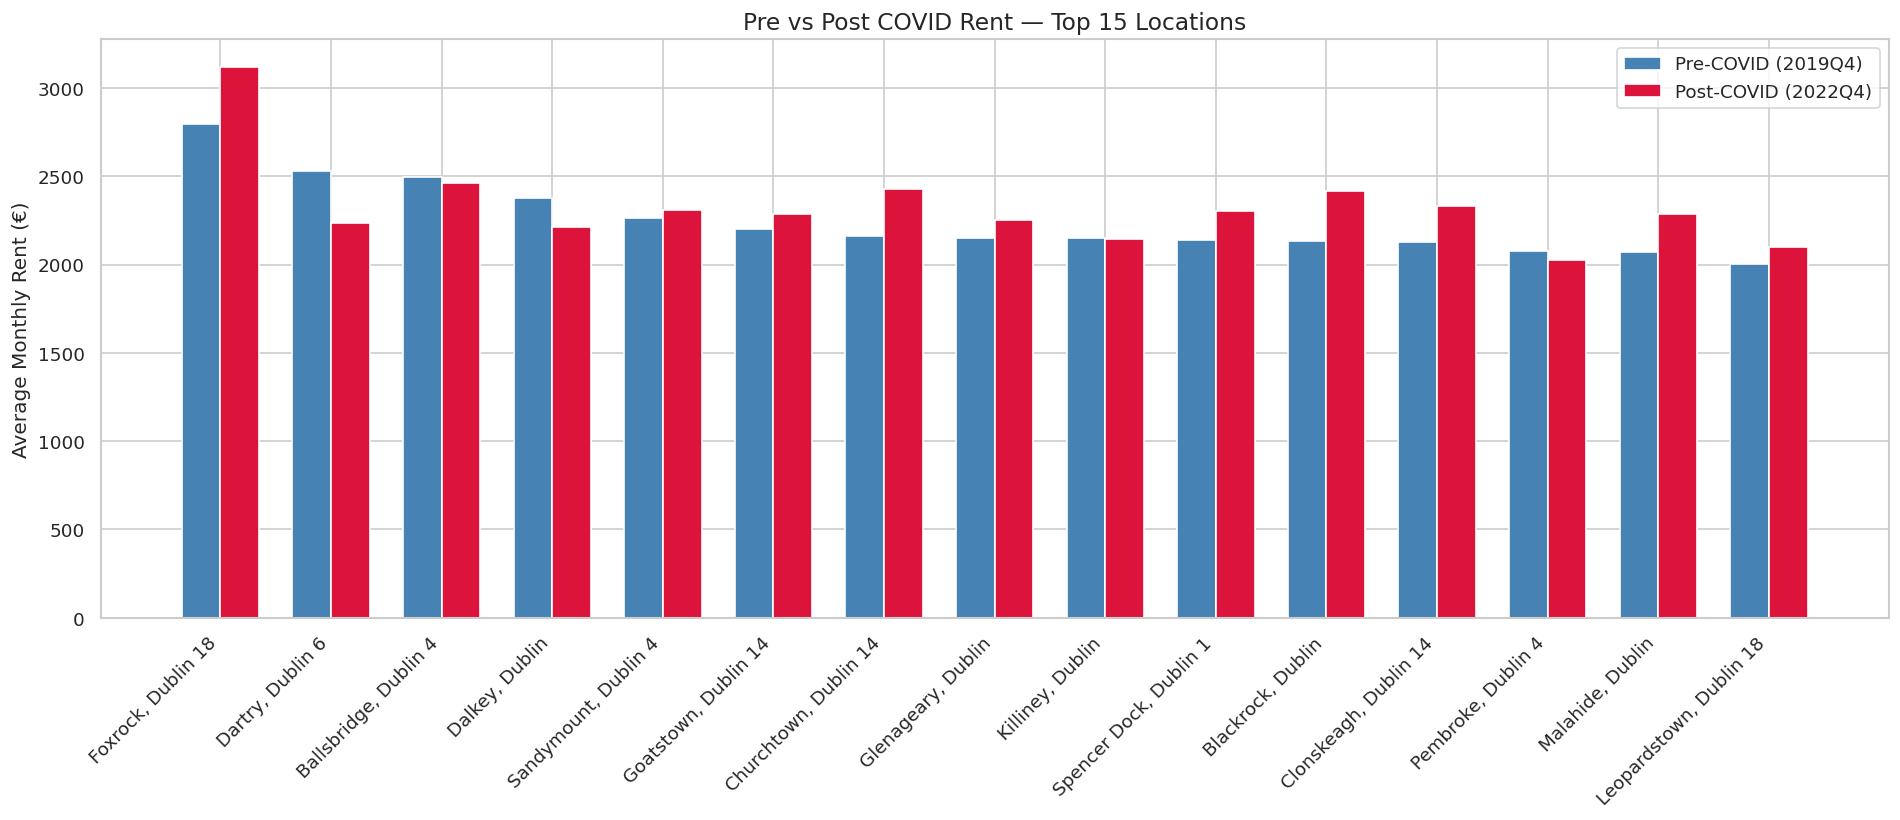

In [20]:
pre_covid_val  = df_q[df_q['Quarter'] == '2019Q4'].groupby('Location')['Value'].mean()
post_covid_val = df_q[df_q['Quarter'] == '2022Q4'].groupby('Location')['Value'].mean()

covid_compare = pd.DataFrame({
    'Pre_COVID_2019Q4'  : pre_covid_val,
    'Post_COVID_2022Q4' : post_covid_val
}).dropna().reset_index()
covid_compare = covid_compare.sort_values('Pre_COVID_2019Q4', ascending=False).head(15)

x     = range(len(covid_compare))
width = 0.35

plt.figure(figsize=(16, 7))
plt.bar([i - width/2 for i in x], covid_compare['Pre_COVID_2019Q4'],
        width, label='Pre-COVID (2019Q4)', color='steelblue')
plt.bar([i + width/2 for i in x], covid_compare['Post_COVID_2022Q4'],
        width, label='Post-COVID (2022Q4)', color='crimson')
plt.xticks(x, covid_compare['Location'], rotation=45, ha='right')
plt.title('Pre vs Post COVID Rent — Top 15 Locations', fontsize=14)
plt.ylabel('Average Monthly Rent (€)')
plt.legend()
plt.tight_layout()
plt.show()

Not a single location in the top 15 ended up cheaper in 2022Q4 than it was in 2019Q4. Every bar on the right is taller than its pair on the left. Whatever brief relief COVID offered was completely reversed and then some within two years.

---
## 6. Is there a seasonal pattern — does it cost more to rent in summer?

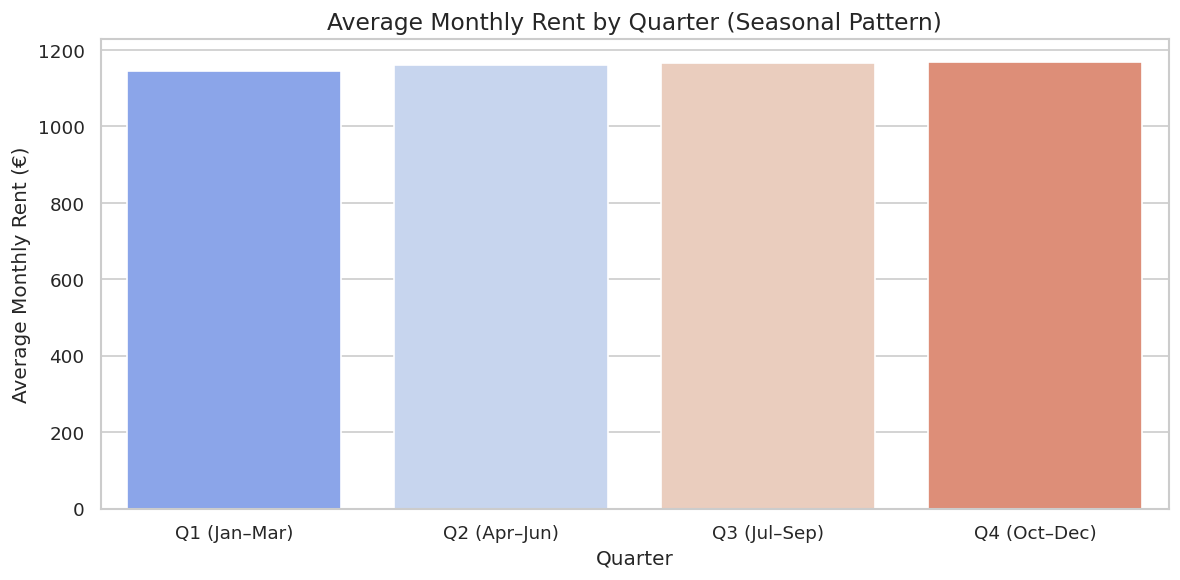

In [21]:
seasonal = df_q.groupby('Q_Num')['Value'].mean().reset_index()
seasonal['Quarter_Label'] = ['Q1 (Jan–Mar)', 'Q2 (Apr–Jun)', 'Q3 (Jul–Sep)', 'Q4 (Oct–Dec)']

plt.figure(figsize=(10, 5))
sns.barplot(data=seasonal, x='Quarter_Label', y='Value', palette='coolwarm')
plt.title('Average Monthly Rent by Quarter (Seasonal Pattern)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Average Monthly Rent (€)')
plt.tight_layout()
plt.show()

Yes — Q3 is the most expensive quarter and Q1 is the cheapest. The difference isn't massive but it's consistent. July to September is when students arrive, leases turn over, and everyone is hunting at the same time. If you have any flexibility on when you move, starting a search in January genuinely saves you money.

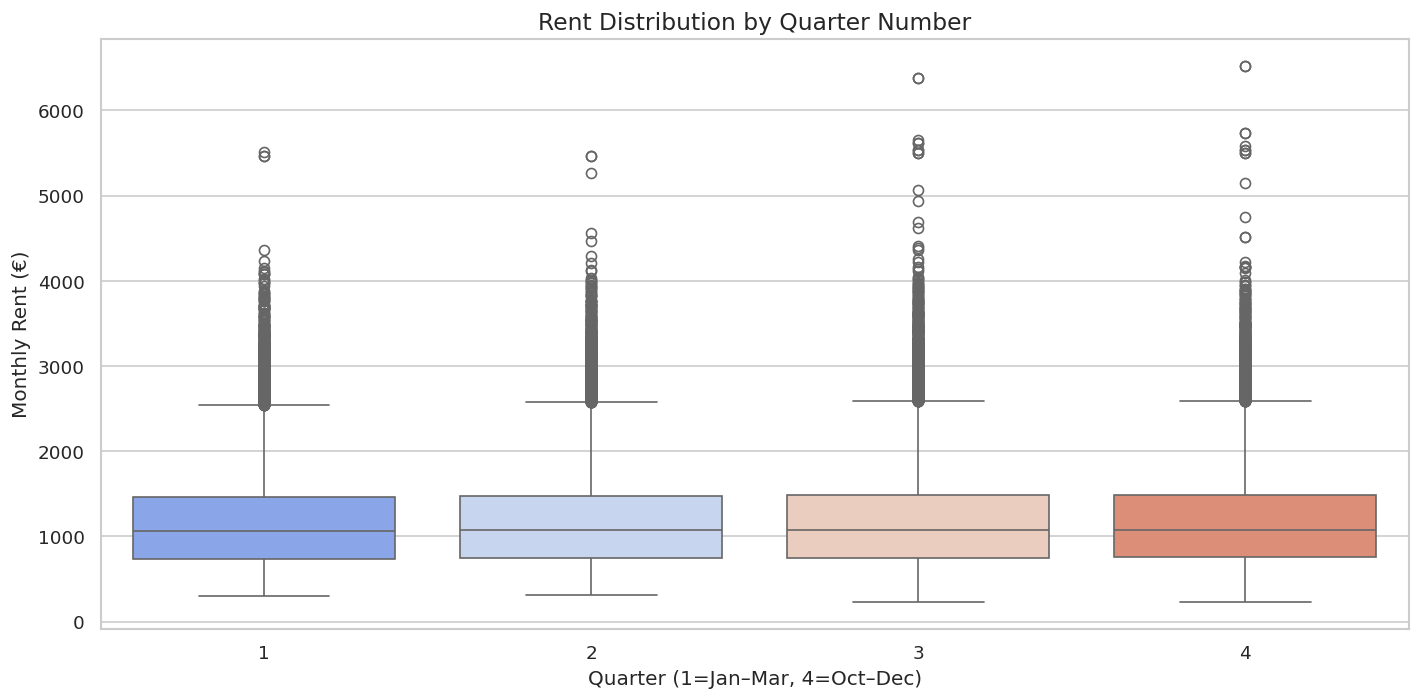

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_q, x='Q_Num', y='Value', palette='coolwarm')
plt.title('Rent Distribution by Quarter Number', fontsize=14)
plt.xlabel('Quarter (1=Jan–Mar, 4=Oct–Dec)')
plt.ylabel('Monthly Rent (€)')
plt.tight_layout()
plt.show()

The medians are close across quarters but Q3 has more high-end outliers. The seasonal premium is most visible at the top of the market — luxury apartments and larger properties see bigger swings. The bottom of the market is less affected by time of year.

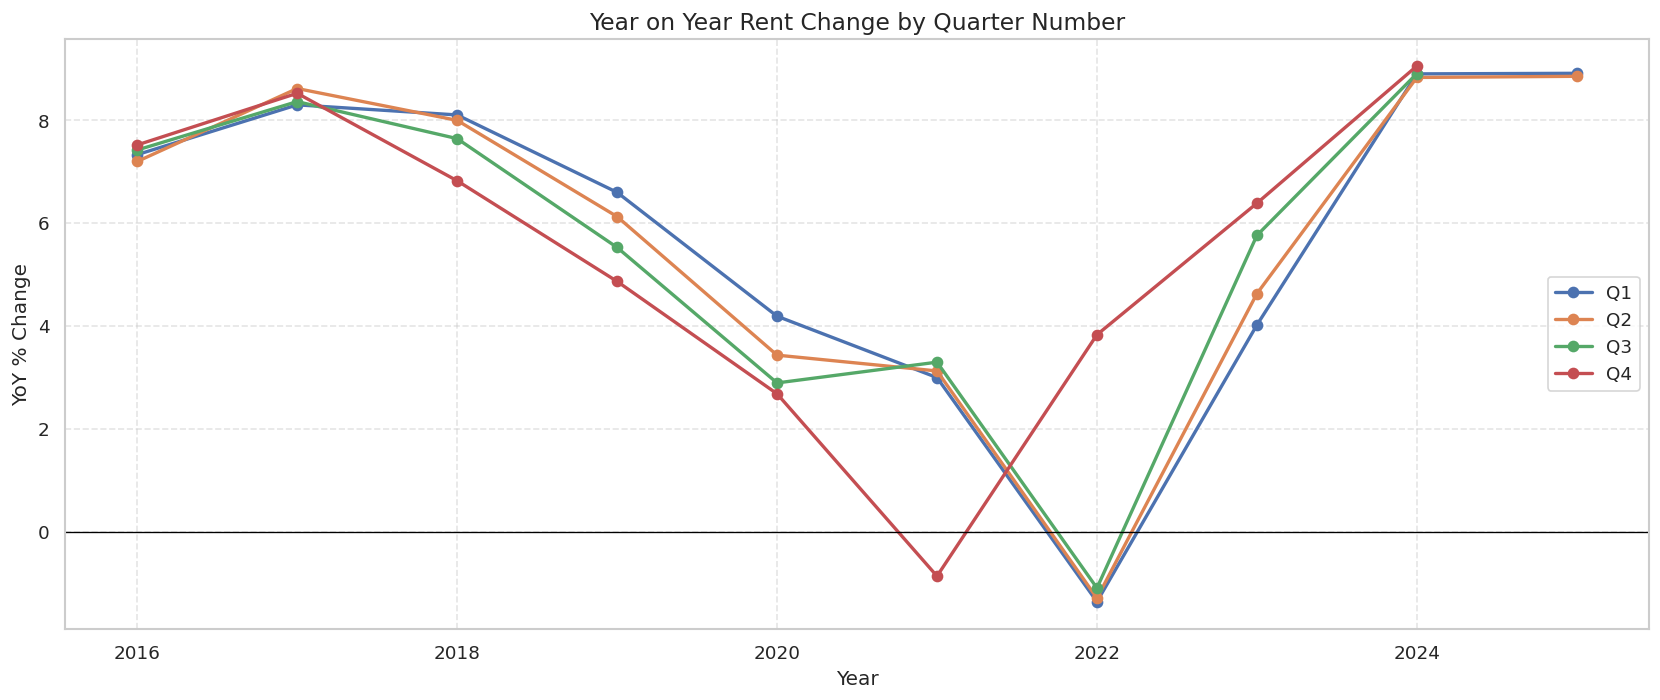

In [23]:
yoy_q = df_q.groupby(['Year', 'Q_Num'])['Value'].mean().reset_index()
yoy_q = yoy_q.sort_values(['Q_Num', 'Year'])
yoy_q['YoY'] = yoy_q.groupby('Q_Num')['Value'].pct_change() * 100

plt.figure(figsize=(14, 6))
for q in [1, 2, 3, 4]:
    data = yoy_q[yoy_q['Q_Num'] == q].dropna()
    plt.plot(data['Year'], data['YoY'], marker='o', label=f'Q{q}', linewidth=2)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Year on Year Rent Change by Quarter Number', fontsize=14)
plt.xlabel('Year')
plt.ylabel('YoY % Change')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

All four quarters dropped together in 2020 and rebounded together in 2021. Outside of COVID the lines track pretty closely — the seasonal pattern is real but it doesn't mean one quarter grows while another doesn't. They all tend to move in the same direction at the same time.

---
## 7. Affordability — who actually can't afford rent anymore?

The 30% threshold is the internationally used benchmark. If you're spending more than 30% of your disposable income on rent you're in housing stress. Let's see how many Irish counties are above that line.

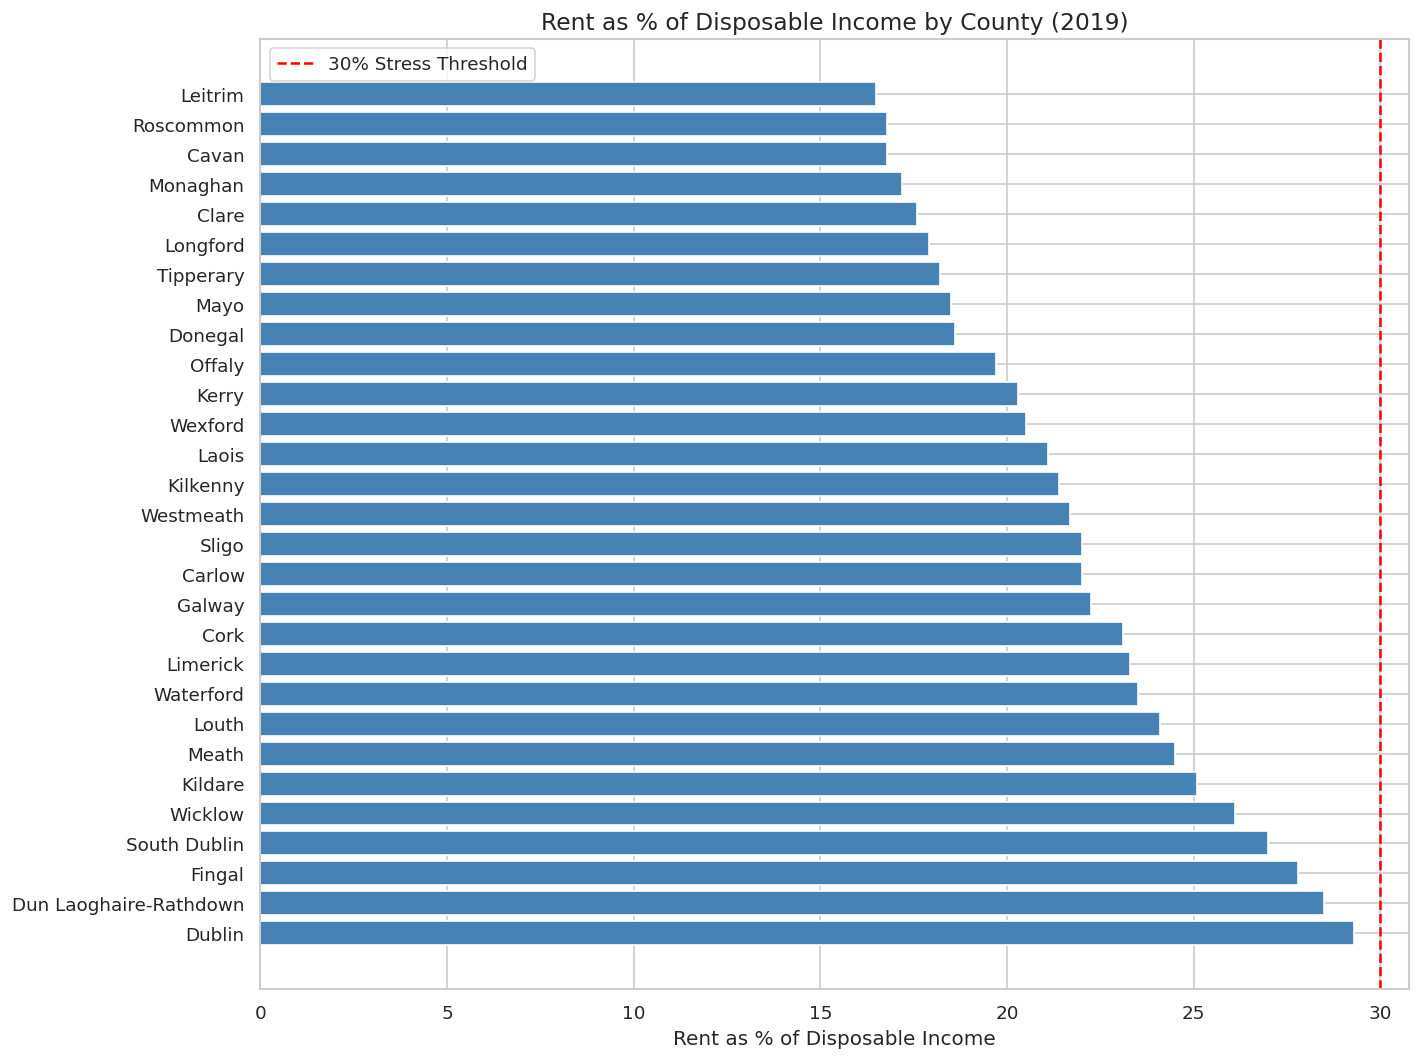

In [24]:
df_cc_sorted = df_cc.sort_values('Rent_Pct_Disposable_Income', ascending=False)

plt.figure(figsize=(12, 9))
colors = ['crimson' if x >= 30 else 'steelblue' for x in df_cc_sorted['Rent_Pct_Disposable_Income']]
plt.barh(df_cc_sorted['County'], df_cc_sorted['Rent_Pct_Disposable_Income'], color=colors)
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label='30% Stress Threshold')
plt.title('Rent as % of Disposable Income by County (2019)', fontsize=14)
plt.xlabel('Rent as % of Disposable Income')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

The red bars are the ones in genuine housing stress. Dublin and its sub-councils are all above 30%. What's striking is how many other counties are close to the line — they're not technically in stress by this measure but they're not far off. This data is from 2019 too — given how much rents have risen since then, the picture today would look considerably worse.

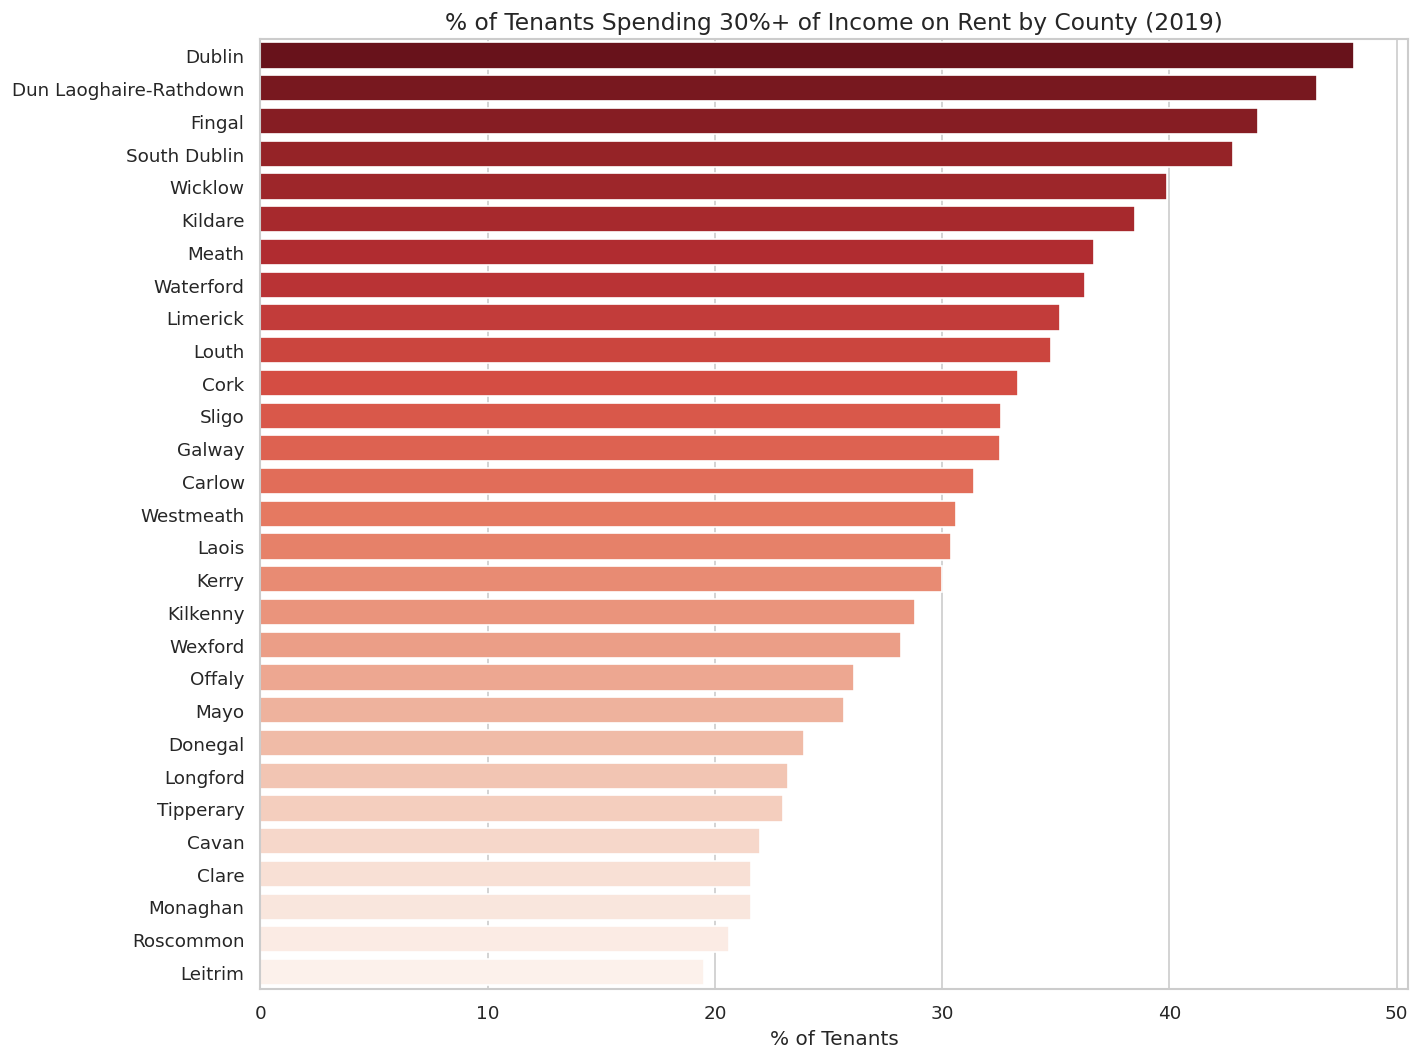

In [25]:
df_cc_30 = df_cc.sort_values('Pct_Tenants_Over30pct', ascending=False)

plt.figure(figsize=(12, 9))
sns.barplot(data=df_cc_30, x='Pct_Tenants_Over30pct', y='County', palette='Reds_r')
plt.title('% of Tenants Spending 30%+ of Income on Rent by County (2019)', fontsize=14)
plt.xlabel('% of Tenants')
plt.ylabel('')
plt.tight_layout()
plt.show()

Nearly half of all tenants in Dublin are spending more than 30% of their income on rent. Even in the most affordable counties the proportion is still significant. This isn't a small problem affecting a few people — it's the majority experience for renters across the country.

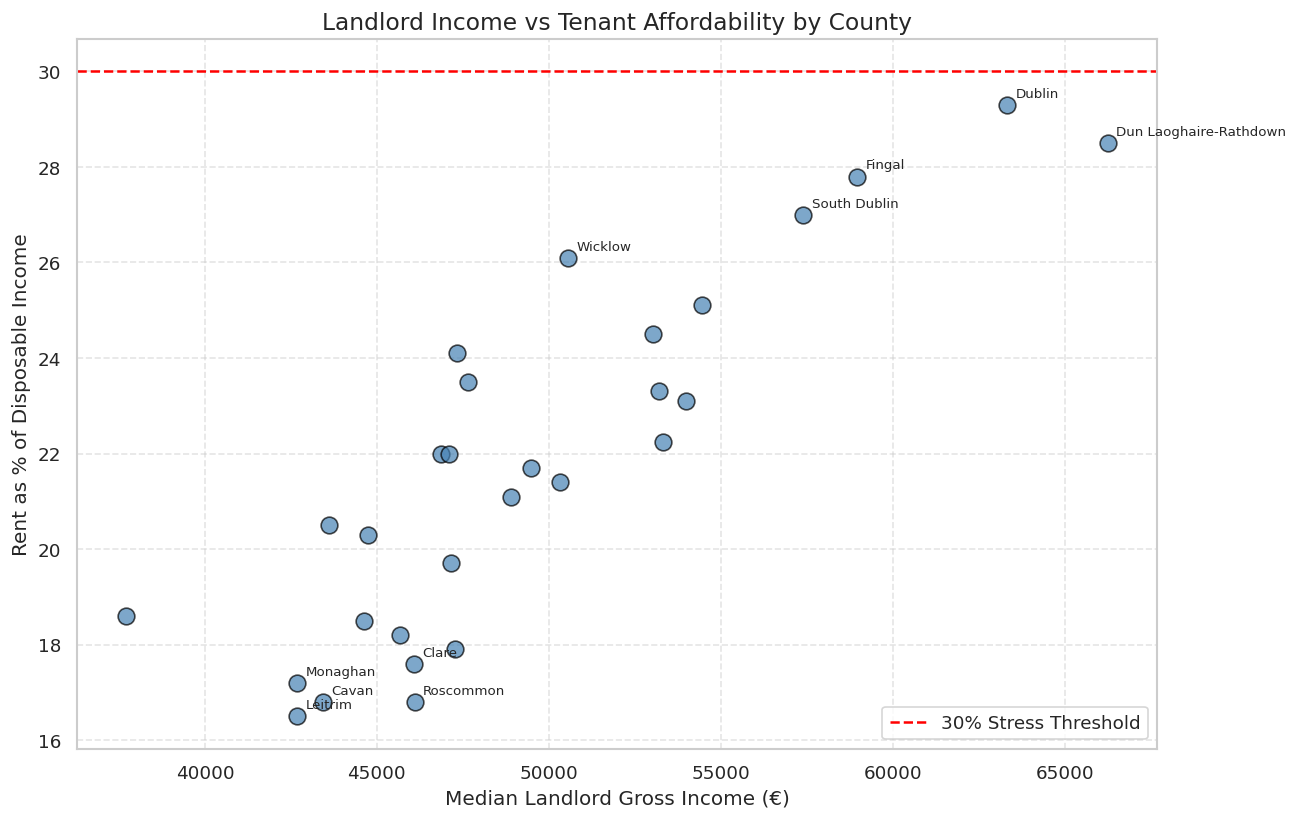

In [26]:
df_cc_sorted_inc = df_cc.sort_values('Rent_Pct_Disposable_Income', ascending=False).reset_index(drop=True)
label_idx = list(df_cc_sorted_inc.head(5).index) + list(df_cc_sorted_inc.tail(5).index)

plt.figure(figsize=(11, 7))
plt.scatter(df_cc['Median_Gross_Income'], df_cc['Rent_Pct_Disposable_Income'],
            s=100, alpha=0.7, color='steelblue', edgecolors='black')

for idx in label_idx:
    row = df_cc_sorted_inc.iloc[idx]
    plt.annotate(row['County'], (row['Median_Gross_Income'], row['Rent_Pct_Disposable_Income']),
                 fontsize=8, ha='left', va='bottom', xytext=(5, 3), textcoords='offset points')

plt.axhline(30, color='red', linestyle='--', label='30% Stress Threshold')
plt.title('Landlord Income vs Tenant Affordability by County', fontsize=14)
plt.xlabel('Median Landlord Gross Income (€)')
plt.ylabel('Rent as % of Disposable Income')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The pattern here is clear — where landlords earn more, tenants struggle more. Dún Laoghaire and Fingal sit at the top right: high landlord income, high affordability stress. Donegal and Leitrim sit bottom left: lower landlord income, lower stress. Both sides of the market are driven by the same underlying pressure — demand.

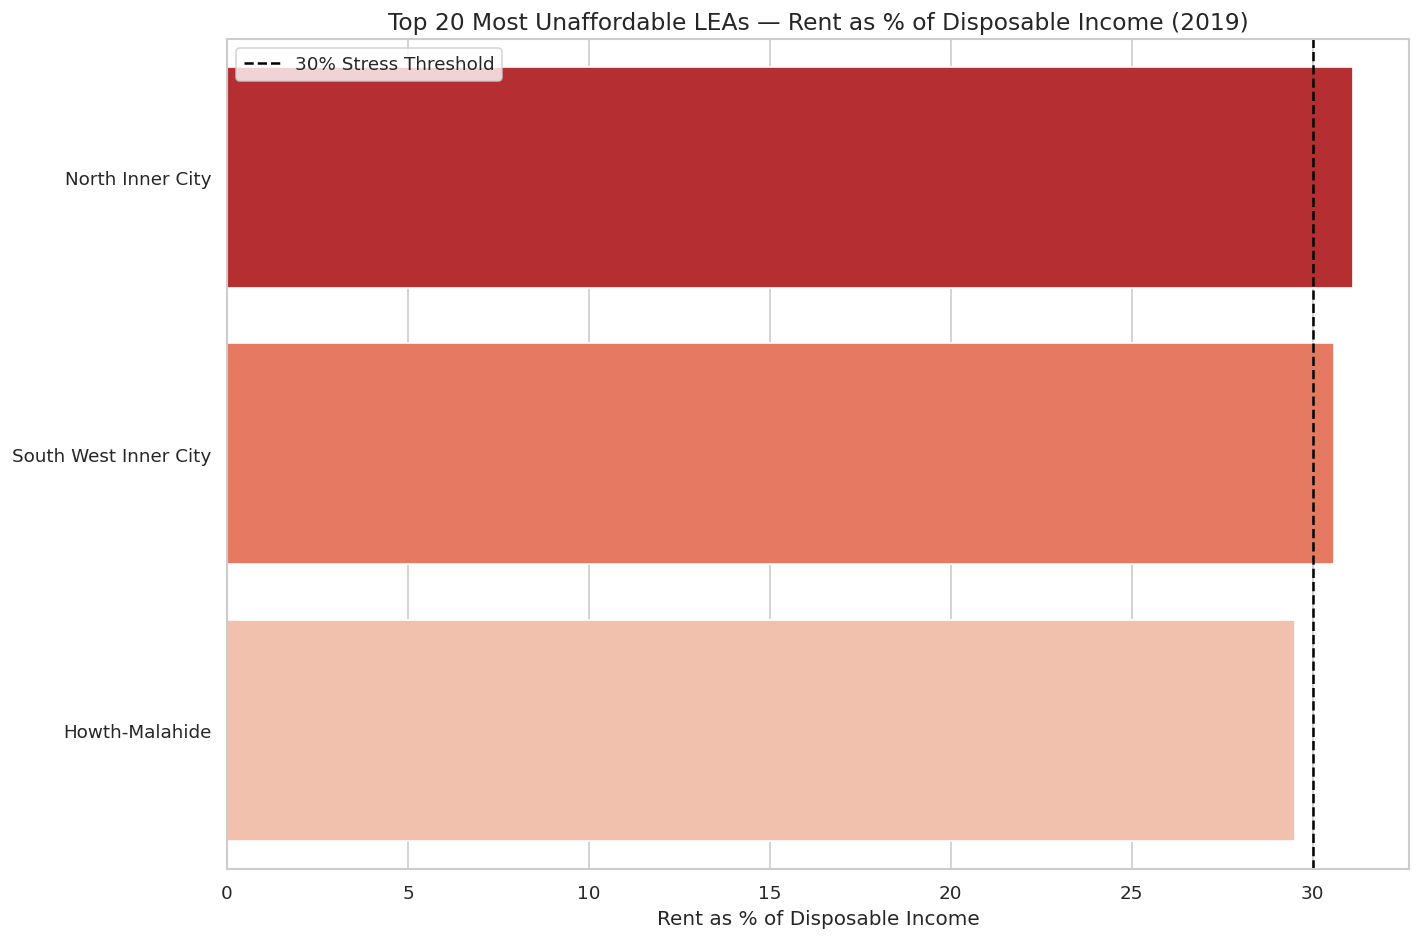

In [27]:
top20_lea = df_lea.sort_values('Rent_Pct_Disposable_Income', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top20_lea, x='Rent_Pct_Disposable_Income', y='Area', palette='Reds_r')
plt.axvline(30, color='black', linestyle='--', label='30% Stress Threshold')
plt.title('Top 20 Most Unaffordable LEAs — Rent as % of Disposable Income (2019)', fontsize=14)
plt.xlabel('Rent as % of Disposable Income')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

At the LEA level it gets even more concentrated. The top 20 most unaffordable LEAs are almost entirely in Dublin city and the inner suburbs. If you're renting in these areas you are almost certainly spending more than a third of your income on rent.

---
## 8. HAP — is the state keeping up with the crisis?

HAP (Housing Assistance Payment) is the main state subsidy for private renters who can't afford market rates. If HAP demand is growing every year, that tells you the market is pricing more and more people out.

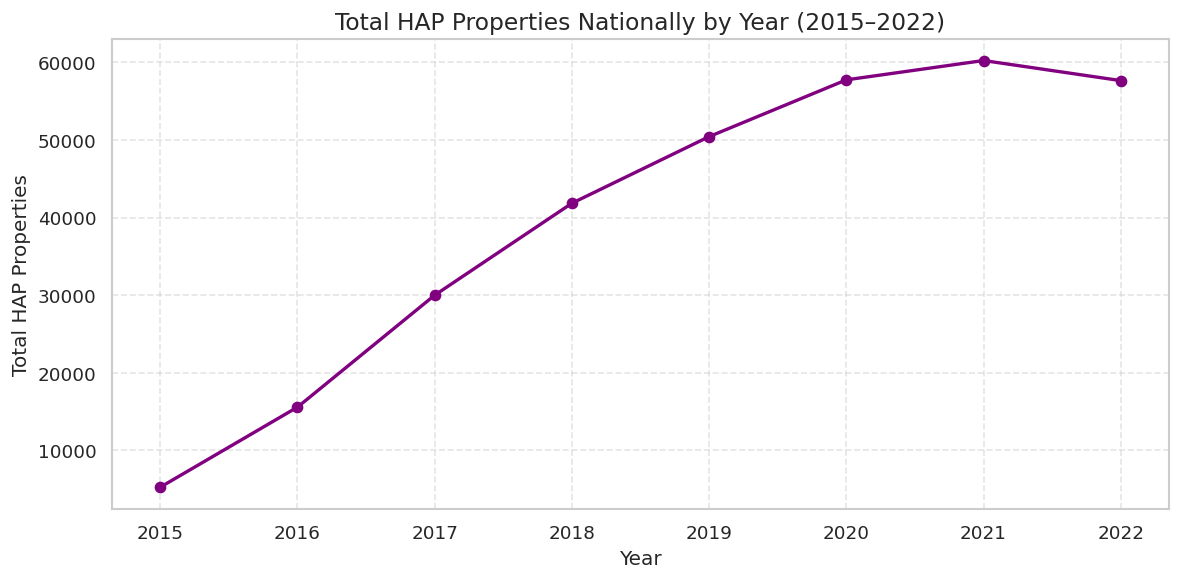

In [28]:
hap_national = df_lea.groupby('Year')['HAP_Properties'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(hap_national['Year'], hap_national['HAP_Properties'], marker='o', color='purple', linewidth=2)
plt.title('Total HAP Properties Nationally by Year (2015–2022)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total HAP Properties')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Up every single year, no exceptions. HAP went from almost nothing in 2015 to tens of thousands of properties by 2022. The scheme was meant to be a transitional measure — the data suggests it became a permanent crutch as the market kept moving beyond what ordinary people could afford.

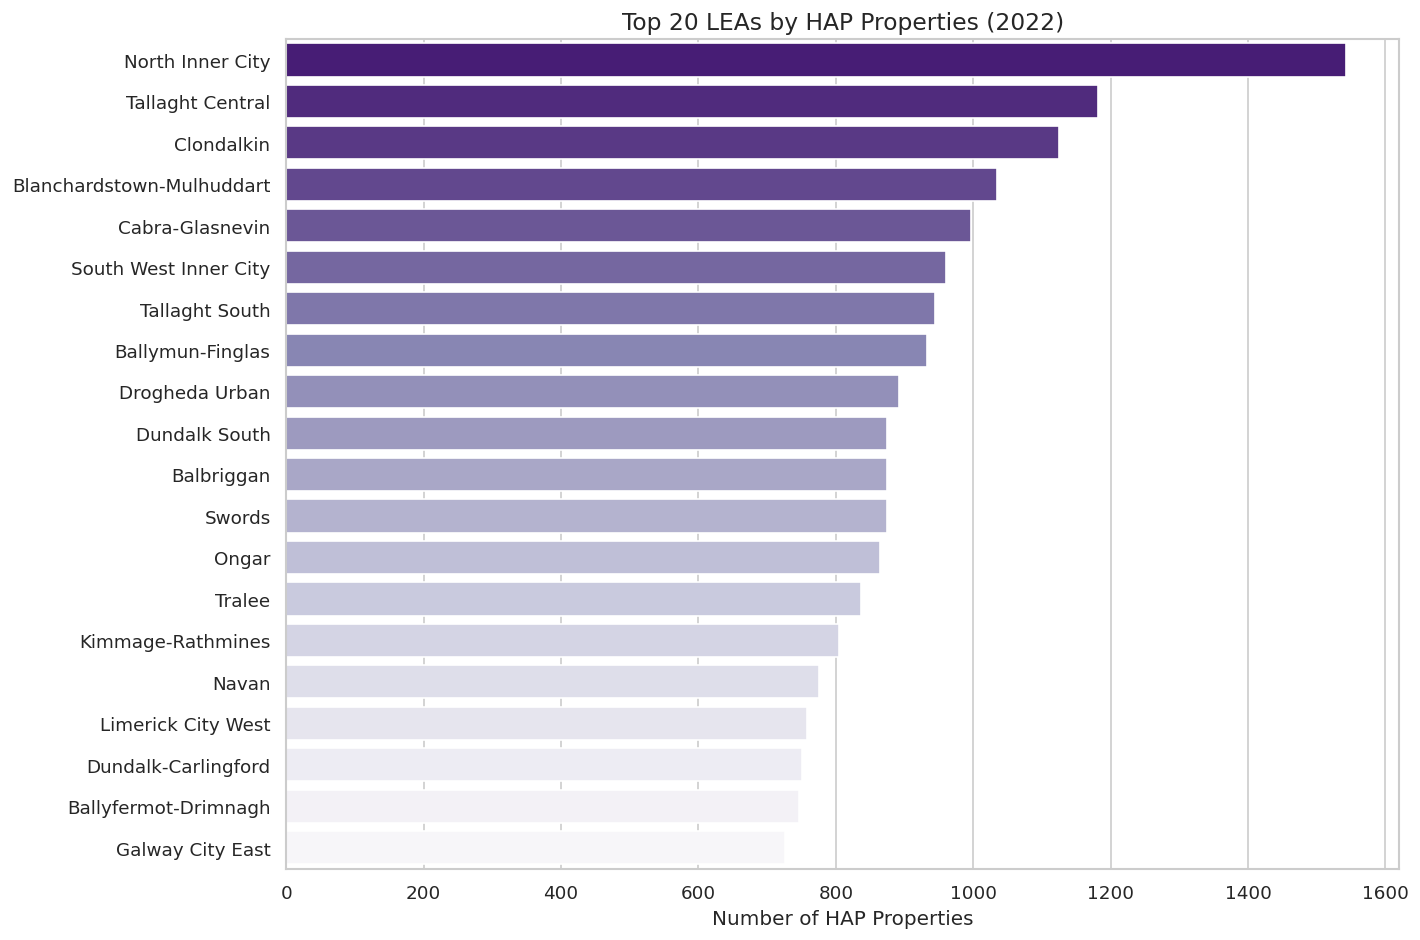

In [29]:
hap_2022 = df_lea[df_lea['Year'] == 2022].sort_values('HAP_Properties', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=hap_2022, x='HAP_Properties', y='Area', palette='Purples_r')
plt.title('Top 20 LEAs by HAP Properties (2022)', fontsize=14)
plt.xlabel('Number of HAP Properties')
plt.ylabel('')
plt.tight_layout()
plt.show()

Dublin LEAs take up almost the entire top 20. The concentration of state-subsidised tenants in specific areas is striking — it mirrors exactly where rents are highest. HAP follows the crisis, it doesn't lead it.

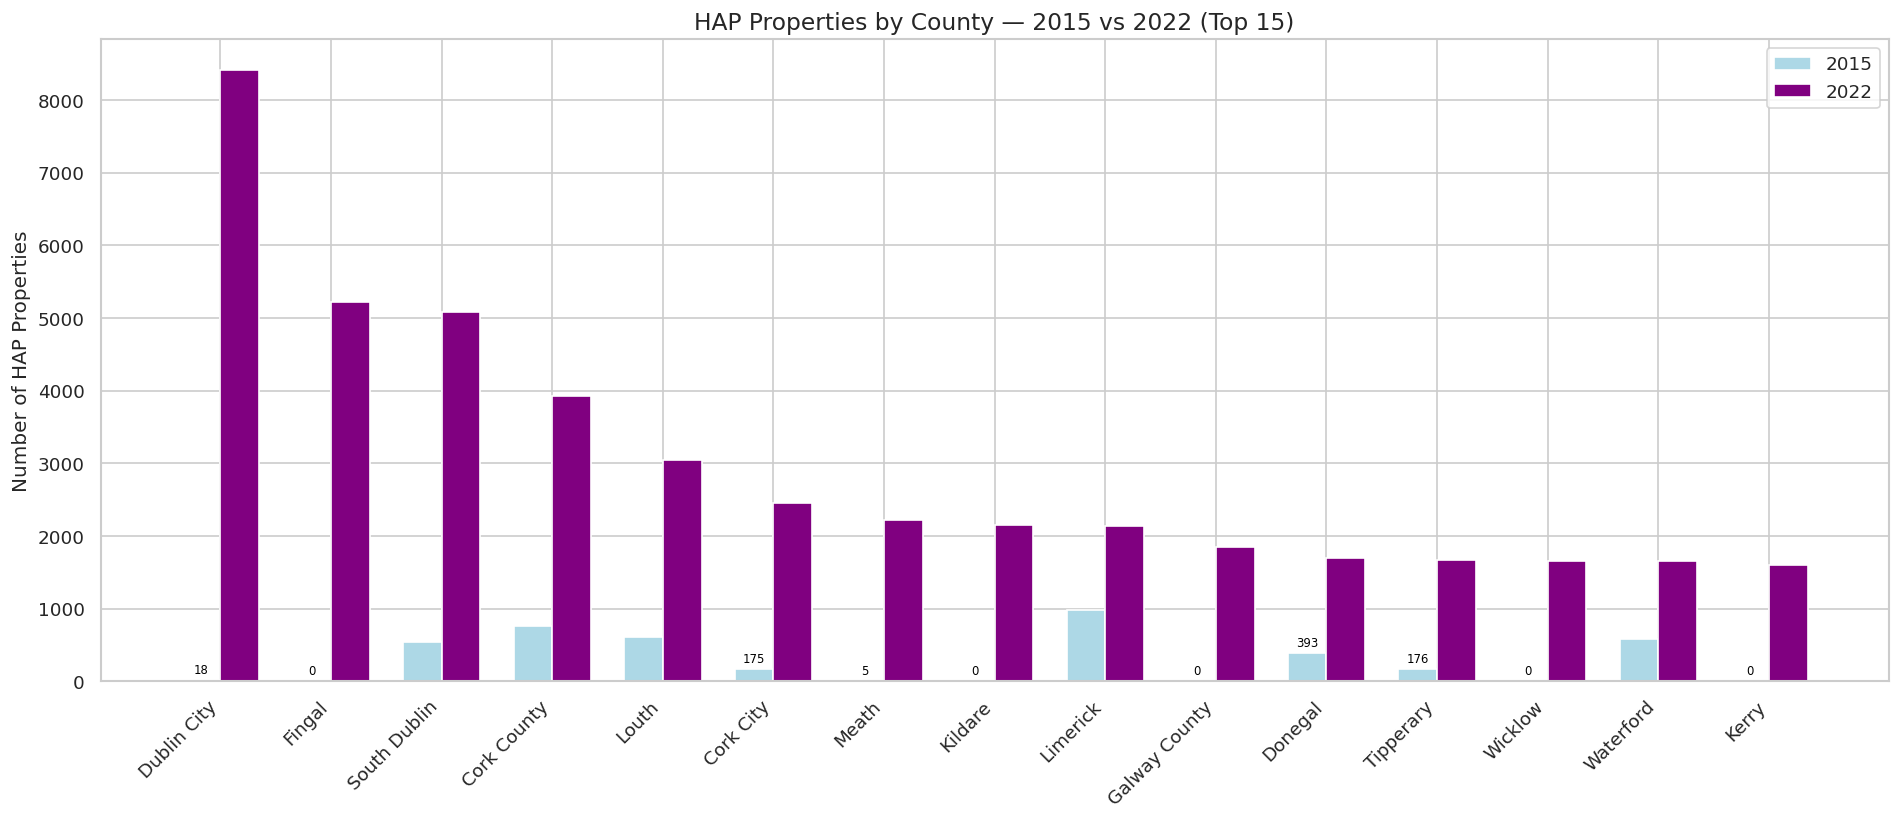

In [42]:
hap_2015_county = df_lea[df_lea['Year'] == 2015].groupby('County')['HAP_Properties'].sum()
hap_2022_county = df_lea[df_lea['Year'] == 2022].groupby('County')['HAP_Properties'].sum()

hap_growth = pd.DataFrame({'HAP_2015': hap_2015_county, 'HAP_2022': hap_2022_county}).dropna()
hap_growth = hap_growth.reset_index().sort_values('HAP_2022', ascending=False).head(15)

x     = range(len(hap_growth))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars_15 = ax.bar([i - width/2 for i in x], hap_growth['HAP_2015'], width, label='2015', color='lightblue')
bars_22 = ax.bar([i + width/2 for i in x], hap_growth['HAP_2022'], width, label='2022', color='purple')

# label the 2015 bars only — these are the ones that are hard to see
for bar, val in zip(bars_15, hap_growth['HAP_2015']):
    if val < 500:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(val)}', ha='center', va='bottom', fontsize=7, color='black')

ax.set_xticks(x)
ax.set_xticklabels(hap_growth['County'], rotation=45, ha='right')
ax.set_title('HAP Properties by County — 2015 vs 2022 (Top 15)', fontsize=14)
ax.set_ylabel('Number of HAP Properties')
ax.legend()
plt.tight_layout()
plt.show()

Dublin's numbers are in a different league to everything else. Cork and Limerick have grown significantly too but they're a fraction of Dublin's scale. The sheer volume of HAP in Dublin tells you how many people in the capital cannot afford market rent without state support.

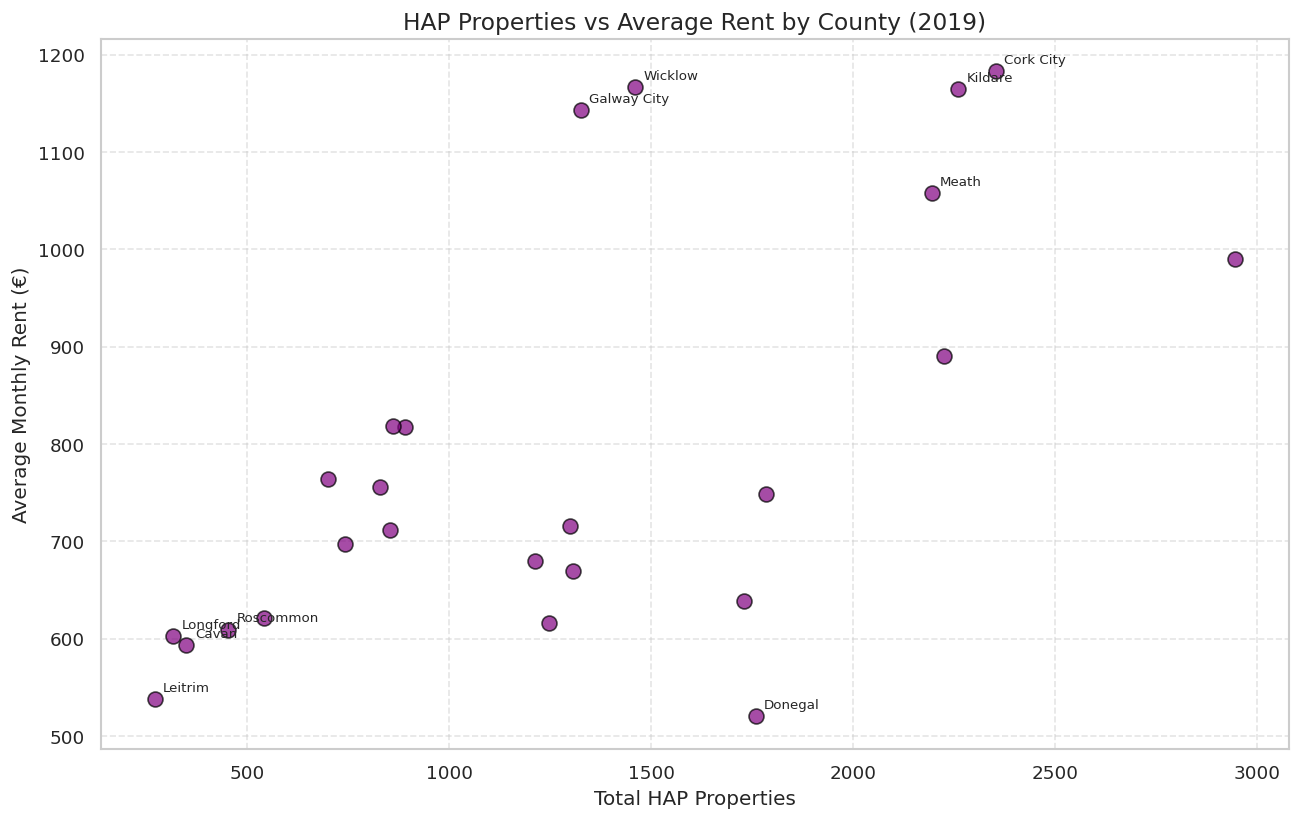

In [31]:
county_rent_2019 = df_q[df_q['Year'] == 2019].groupby('Location')['Value'].mean().reset_index()
county_rent_2019.columns = ['County', 'Avg_Rent']
hap_2019_county = df_lea[df_lea['Year'] == 2019].groupby('County')['HAP_Properties'].sum().reset_index()
hap_rent = hap_2019_county.merge(county_rent_2019, on='County', how='inner')
hap_rent_sorted = hap_rent.sort_values('Avg_Rent', ascending=False).reset_index(drop=True)
label_idx = list(hap_rent_sorted.head(5).index) + list(hap_rent_sorted.tail(5).index)

plt.figure(figsize=(11, 7))
plt.scatter(hap_rent['HAP_Properties'], hap_rent['Avg_Rent'],
            alpha=0.7, color='purple', edgecolors='black', s=80)

for idx in label_idx:
    row = hap_rent_sorted.iloc[idx]
    plt.annotate(row['County'], (row['HAP_Properties'], row['Avg_Rent']),
                 fontsize=8, ha='left', va='bottom', xytext=(5, 3), textcoords='offset points')

plt.title('HAP Properties vs Average Rent by County (2019)', fontsize=14)
plt.xlabel('Total HAP Properties')
plt.ylabel('Average Monthly Rent (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

More HAP, higher rent. The two move together. This doesn't mean HAP causes high rent — it means HAP is concentrated exactly where the market is most unaffordable, which is exactly where you'd expect it to be needed most.

---
## 9. What actually drives rent? — correlation analysis

In [32]:
county_rent_2019 = df_q[df_q['Year'] == 2019].groupby('Location')['Value'].mean().reset_index()
county_rent_2019.columns = ['County', 'Avg_Rent']
corr_df = df_cc.merge(county_rent_2019, on='County', how='inner')

print(f'Counties in dataset: {len(corr_df)}')
corr_df.head()

Counties in dataset: 26


,Year,County,Median_Gross_Income,Rent_Pct_Disposable_Income,Pct_Tenants_Over30pct,Population,Avg_Rent
0,2019,Carlow,46865.0,22.0,31.40,61968.0,764.178897
1,2019,Cavan,43437.0,16.8,22.00,81704.0,593.210388
2,2019,Clare,46078.0,17.6,21.60,127938.0,669.301029
3,2019,Cork,53993.5,23.1,33.35,584156.0,1004.492500
4,2019,Donegal,37709.0,18.6,23.90,167084.0,520.258571


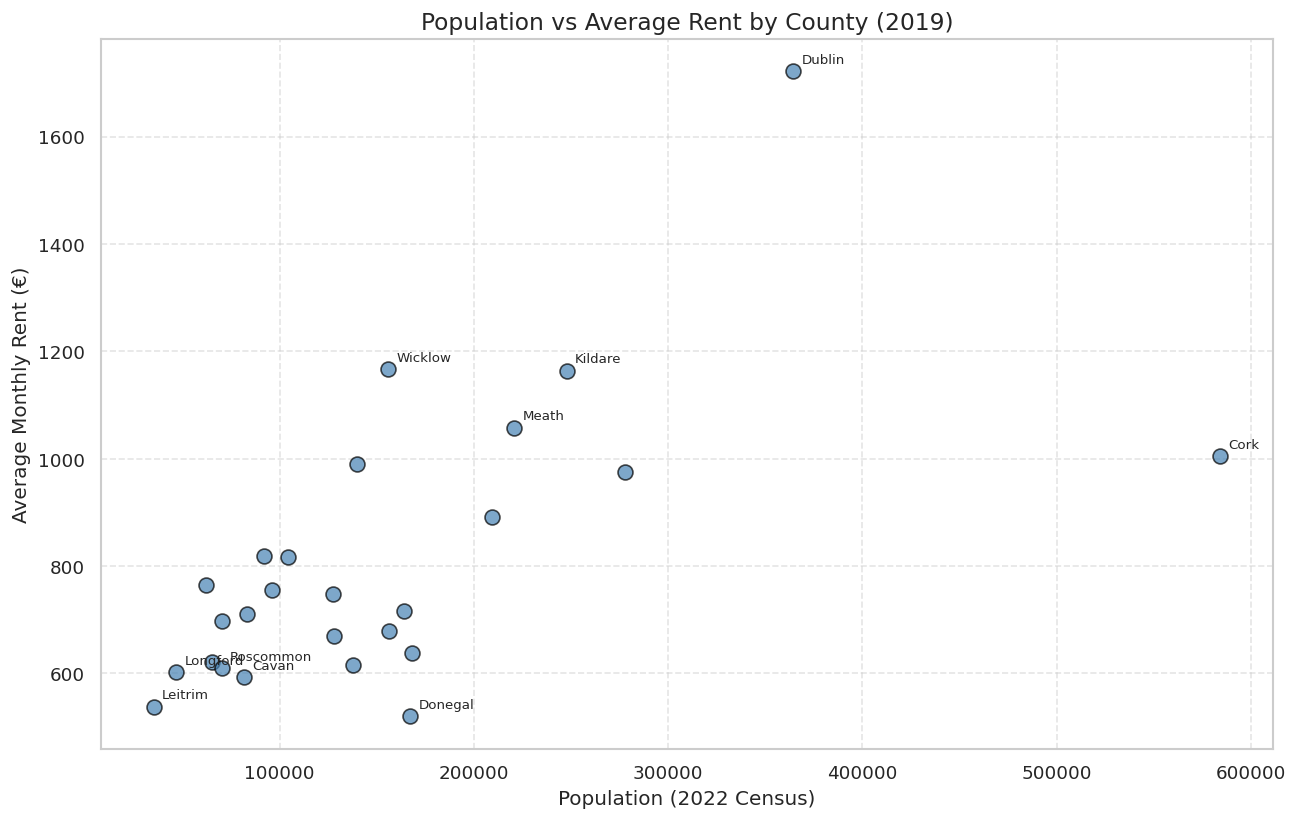

In [33]:
corr_sorted = corr_df.sort_values('Avg_Rent', ascending=False).reset_index(drop=True)
label_idx   = list(corr_sorted.head(5).index) + list(corr_sorted.tail(5).index)

plt.figure(figsize=(11, 7))
plt.scatter(corr_df['Population'], corr_df['Avg_Rent'],
            alpha=0.7, color='steelblue', edgecolors='black', s=80)

for idx in label_idx:
    row = corr_sorted.iloc[idx]
    plt.annotate(row['County'], (row['Population'], row['Avg_Rent']),
                 fontsize=8, ha='left', va='bottom', xytext=(5, 3), textcoords='offset points')

plt.title('Population vs Average Rent by County (2019)', fontsize=14)
plt.xlabel('Population (2022 Census)')
plt.ylabel('Average Monthly Rent (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Population and rent track each other fairly well — more people in an area, higher the rent. Dublin is the obvious outlier at the top right. The western counties cluster at the bottom left. Not a perfect relationship (Kildare and Meath have relatively high rent for their population size) but the trend is clear.

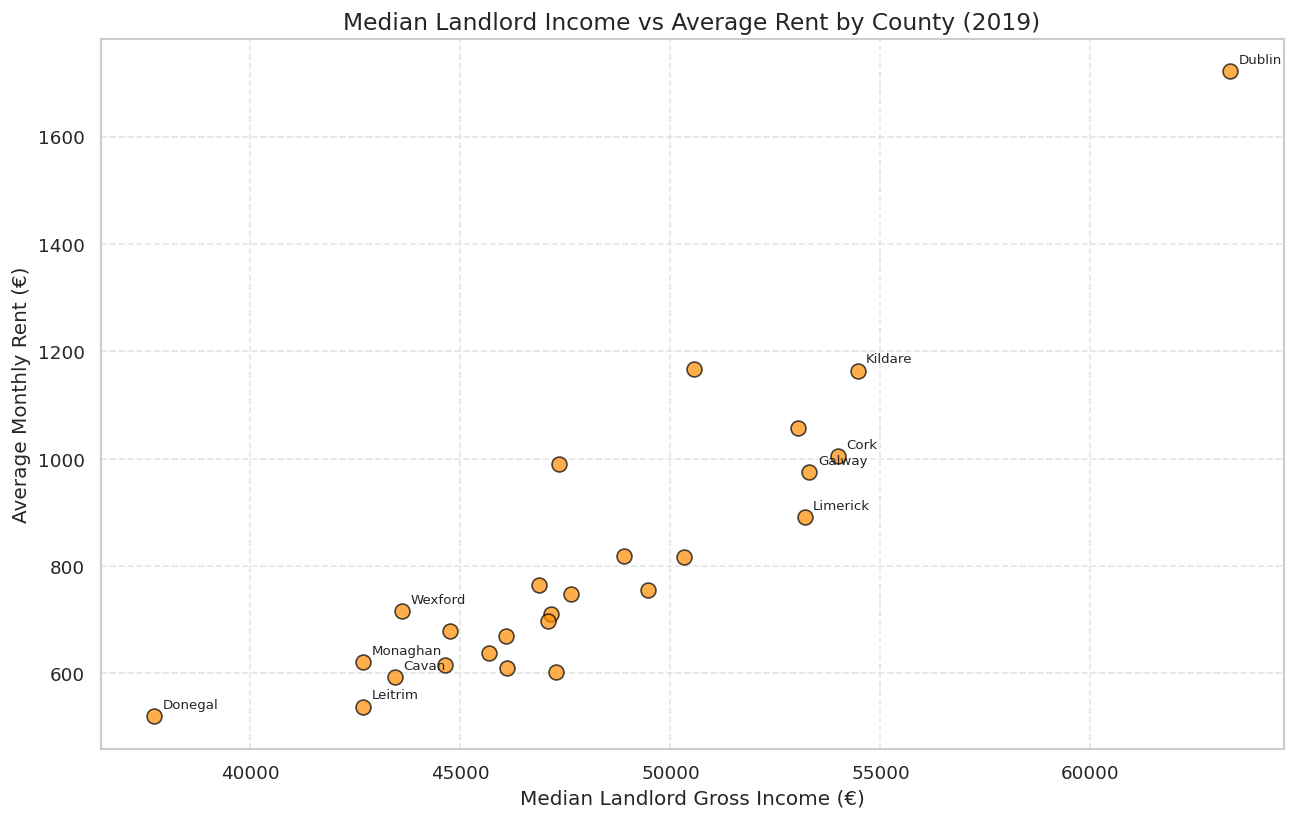

In [34]:
corr_sorted2 = corr_df.sort_values('Median_Gross_Income', ascending=False).reset_index(drop=True)
label_idx2   = list(corr_sorted2.head(5).index) + list(corr_sorted2.tail(5).index)

plt.figure(figsize=(11, 7))
plt.scatter(corr_df['Median_Gross_Income'], corr_df['Avg_Rent'],
            alpha=0.7, color='darkorange', edgecolors='black', s=80)

for idx in label_idx2:
    row = corr_sorted2.iloc[idx]
    plt.annotate(row['County'], (row['Median_Gross_Income'], row['Avg_Rent']),
                 fontsize=8, ha='left', va='bottom', xytext=(5, 3), textcoords='offset points')

plt.title('Median Landlord Income vs Average Rent by County (2019)', fontsize=14)
plt.xlabel('Median Landlord Gross Income (€)')
plt.ylabel('Average Monthly Rent (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Landlord income and rent level are tightly correlated. In high-rent counties landlords earn significantly more. This makes intuitive sense but it's worth stating clearly — the high-cost rental market is also a high-income landlord market. Both sides of the equation are shaped by the same demand pressure.

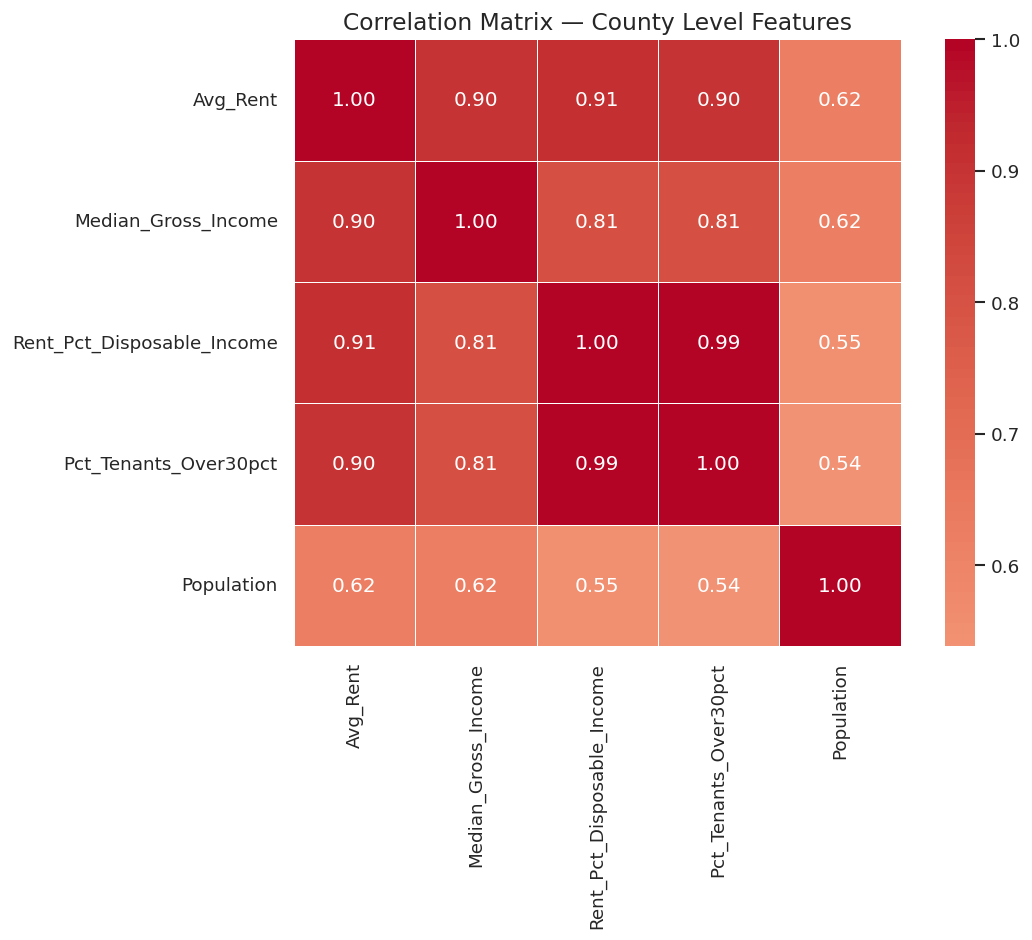

In [35]:
corr_cols   = ['Avg_Rent', 'Median_Gross_Income', 'Rent_Pct_Disposable_Income', 'Pct_Tenants_Over30pct', 'Population']
corr_matrix = corr_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix — County Level Features', fontsize=14)
plt.tight_layout()
plt.show()

The matrix pulls everything together. Avg_Rent correlates strongly with Median_Gross_Income and both affordability metrics. Population has a moderate positive correlation with rent. The two affordability columns (Rent_Pct and Pct_Over30) are almost perfectly correlated with each other — they're measuring the same underlying thing. These relationships will feed directly into feature selection for the ML model in Notebook 06.

---
## 10. Summary — what does the data actually tell us?

In [36]:
print('=' * 60)
print('KEY FINDINGS — NOTEBOOK 03')
print('=' * 60)

start_rent   = national_q['Value'].iloc[0]
end_rent     = national_q['Value'].iloc[-1]
total_growth = ((end_rent - start_rent) / start_rent) * 100
print(f'\n1. National average rent grew {total_growth:.1f}% from 2015 to latest quarter')
print(f'   From €{start_rent:.0f} to €{end_rent:.0f} per month')

print(f'\n2. Most expensive: {county_latest.iloc[0]["Location"]} — €{county_latest.iloc[0]["Value"]:.0f}/month')
print(f'   Most affordable: {county_latest.iloc[-1]["Location"]} — €{county_latest.iloc[-1]["Value"]:.0f}/month')

dublin_now   = dublin_avg['Value'].iloc[-1]
national_now = national_q['Value'].iloc[-1]
dublin_prem  = ((dublin_now - national_now) / national_now) * 100
print(f'\n3. Dublin is {dublin_prem:.1f}% above the national average — and the gap is still widening')

print(f'\n4. Fastest growing since 2015: {growth.iloc[0]["Location"]} — {growth.iloc[0]["Growth_Pct"]:.1f}% increase')

print(f'\n5. COVID caused a short dip in 2020 — every location had fully recovered and exceeded pre-COVID levels by 2022')

q3_avg = df_q[df_q['Q_Num'] == 3]['Value'].mean()
q1_avg = df_q[df_q['Q_Num'] == 1]['Value'].mean()
print(f'\n6. Q3 (Jul-Sep) is consistently the most expensive quarter — €{q3_avg:.0f} avg vs €{q1_avg:.0f} in Q1')

above30 = df_cc[df_cc['Rent_Pct_Disposable_Income'] >= 30]
worst   = df_cc.sort_values('Rent_Pct_Disposable_Income', ascending=False).iloc[0]
print(f'\n7. {len(above30)} counties are above the 30% housing stress threshold')
print(f'   Worst: {worst["County"]} at {worst["Rent_Pct_Disposable_Income"]:.1f}% of disposable income')

hap_2015_t = df_lea[df_lea['Year'] == 2015]['HAP_Properties'].sum()
hap_2022_t = df_lea[df_lea['Year'] == 2022]['HAP_Properties'].sum()
hap_pct    = ((hap_2022_t - hap_2015_t) / hap_2015_t) * 100
print(f'\n8. HAP demand grew {hap_pct:.1f}% from 2015 to 2022 — state support is expanding, not contracting')

print(f'\n9. 1-bed renters pay the highest cost per bedroom in the market')
print(f'   Living alone in Dublin is the most financially punishing rental situation')

print(f'\n10. Rent level correlates with landlord income, population, and affordability stress')
print(f'    These features will be used in the ML model — Notebook 06')

print('\n' + '=' * 60)
print('Next: Notebook 04 — Feature Engineering & Preprocessing')
print('=' * 60)

KEY FINDINGS — NOTEBOOK 03

1. National average rent grew 76.6% from 2015 to latest quarter
   From €873 to €1543 per month

2. Most expensive: Foxrock, Dublin 18 — €3633/month
   Most affordable: Carndonagh, Donegal — €725/month

3. Dublin is 33.3% above the national average — and the gap is still widening

4. Fastest growing since 2015: Tubbercurry, Sligo — 181.2% increase

5. COVID caused a short dip in 2020 — every location had fully recovered and exceeded pre-COVID levels by 2022

6. Q3 (Jul-Sep) is consistently the most expensive quarter — €1166 avg vs €1145 in Q1

7. 0 counties are above the 30% housing stress threshold
   Worst: Dublin at 29.3% of disposable income

8. HAP demand grew 992.8% from 2015 to 2022 — state support is expanding, not contracting

9. 1-bed renters pay the highest cost per bedroom in the market
   Living alone in Dublin is the most financially punishing rental situation

10. Rent level correlates with landlord income, population, and affordability stress